# **01. [Lung] Preparation and Data Analysis**

## **Introduction**

Preparation and Analysis of RHC-SP Lung Data for the Machine Learning Survival Study

## Environment Settings

In [ ]:
# download the file that contains the requirement management functions
!gdown 1563shEptjQS10FQbqjM-QsXot_cvHJBL --quiet
%run /content/bootstrap.py

# mount google drive
from google.colab import drive
drive.mount('/content/drive')

# put here the your Drive's path to the project
LOCAL_PROJECT_PATH = "/content/drive/MyDrive/Trabalho/Câncer/ML de Sobrevida"

set_project(LOCAL_PROJECT_PATH)
setup()

Mounted at /content/drive
Projeto definido: /content/drive/MyDrive/Trabalho/Câncer/ML de Sobrevida

Grupos disponíveis:
1. data_analysis
2. ml
3. Criar novo grupo

Escolha (ex: 1,3): 1

Lendo dependências de data_analysis:
  - lifelines==0.30.3
  - matplotlib==3.10.0
  - numpy==2.0.2
  - pandas==2.2.2
  - plotly==5.24.1
  - scikit-learn==1.6.1
  - seaborn==0.13.2

 Instalando dependências necessárias:
 + lifelines==0.30.3

⚠️ Dependências instaladas.
Reiniciando o kernel automaticamente...


<IPython.core.display.Javascript object>

### Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer

from lifelines.statistics import logrank_test
from lifelines import KaplanMeierFitter

## Functions

In [ ]:
def preparing_dataset(df):
    """
    Prepares the dataset for analysis, applying necessary filters and transformations.

    Parameters:
    -----------
    df : pandas.DataFrame
        The dataset to be prepared.

    Returns:
    --------
    pandas.DataFrame
        The dataset after the transformations.
    """

    df_aux = df.copy()

    # Lung Cancer Topography (C34) - Filter for lung cancer
    df_aux = df_aux[df_aux.TOPOGRUP == 'C34']
    print(df_aux.shape)

    # Residency - Filter for residents of SP
    df_aux = df_aux[df_aux.UFRESID == 'SP']

    # Microscopic Confirmation - Filter for records with microscopic confirmation (BASEDIAG == 3)
    df_aux = df_aux[df_aux.BASEDIAG == 3]

    # ECGRUP - Remove records with ECGRUP equal to 0, X or Y
    df_aux = df_aux[~df_aux.ECGRUP.isin(['0','X','Y'])]

    # ECGRUP Categorization - Categorize ECGRUP into 'Inicial' and 'Avançado'
    df_aux['ECGRUP_CAT'] = ['Inicial' if ec in ['I', 'II'] else 'Avançado' for ec in df_aux.ECGRUP]

    # HORMONIO and HORMOAPOS - Remove patients who underwent HORMONIO and HORMOAPOS
    df_aux = df_aux[df_aux.HORMONIO == 0]
    df_aux = df_aux[df_aux.HORMOAPOS == 0]

    # TMO and TMOAPOS - Remove patients who underwent TMO and TMOAPOS
    df_aux = df_aux[df_aux.TMO == 0]
    df_aux = df_aux[df_aux.TMOAPOS == 0]

    # ANODIAG - Filter for diagnosis year before 2020 (commented out)
    # df_aux = df_aux[df_aux.ANODIAG < 2020]

    # Age - Remove age ranges 0-9 and 10-19
    df_aux = df_aux[~df_aux.FAIXAETAR.isin(['00-09', '10-19'])]

    # Date Columns - Convert to datetime objects
    list_datas = ['DTCONSULT', 'DTDIAG', 'DTTRAT', 'DTULTINFO']

    for col_data in list_datas:
        df_aux[col_data] = pd.to_datetime(df_aux[col_data])

    # Time Calculations - Calculate time differences in days
    df_aux['CONSDIAG'] = (df_aux.DTDIAG - df_aux.DTCONSULT).dt.days
    df_aux['DIAGTRAT'] = (df_aux.DTTRAT - df_aux.DTDIAG).dt.days
    df_aux['TRATCONS'] = (df_aux.DTTRAT - df_aux.DTCONSULT).dt.days
    df_aux['ULTIDIAG'] = (df_aux.DTULTINFO - df_aux.DTDIAG).dt.days
    # df_aux['ULTIDIAG_M'] = (df_aux.DTULTINFO - df_aux.DTDIAG).dt.months  # Commented out

    # # Function to calculate the difference in months (commented out)
    # df_aux['ULTIDIAG_M'] = df_aux.apply(lambda row: relativedelta(row['DTULTINFO'], row['DTDIAG']).months +
    #                                     12 * (relativedelta(row['DTULTINFO'], row['DTDIAG']).years), axis=1)

    df_aux[['DIAGTRAT', 'TRATCONS']] = df_aux[['DIAGTRAT', 'TRATCONS']].fillna(-1)

    # Time Categories - Create categorical variables for time differences
    df_aux['CONSDIAG_CAT'] = [0 if consdiag <= 30 else 1 if consdiag <= 60 else 2 for consdiag in df_aux.CONSDIAG]
    df_aux['TRATCONS_CAT'] = [3 if tratcons < 0 else 0 if tratcons <= 60 else 1 if tratcons <= 90 else 2 for tratcons in df_aux.TRATCONS]
    df_aux['DIAGTRAT_CAT'] = [3 if diagtrat < 0 else 0 if diagtrat <= 60 else 1 if diagtrat <= 90 else 2 for diagtrat in df_aux.DIAGTRAT]

    # DRS - Extract DRS number
    DRS_expand = df_aux.DRS.str.split(' ', expand=True)
    df_aux['DRS'] = DRS_expand[1]

    # DRS_INST - Extract DRS_INST number
    DRS_expand = df_aux.DRS_INST.str.split(' ', expand=True)
    df_aux['DRS_INST'] = DRS_expand[1]

    # Metastasis Presence - Create a column indicating the presence of metastasis
    df_aux['PRESENCA_META'] = 0
    df_aux.loc[df_aux.META01.notnull(), 'PRESENCA_META'] = 1

    # Recurrence Presence - Create a variable for presence of recurrence (0 = No, 1 = Yes)
    df_aux['PRESENCA_REC'] = [0 if rec == 1 else 1 for rec in df_aux.RECNENHUM]
    df_aux.loc[(df_aux.PRESENCA_REC == 0) & (df_aux.DTRECIDIVA.notnull()), 'PRESENCA_REC'] = 1

    # Outcome Variables - Create outcome variables (overall survival, cancer-specific survival, and survival at 1, 2, 3, 4 and 5 years)
    df_aux['obito_geral'] = 0
    df_aux['obito_cancer'] = 0

    df_aux['sobrevida_ano1'] = 0
    df_aux['sobrevida_ano2'] = 0
    df_aux['sobrevida_ano3'] = 0
    df_aux['sobrevida_ano4'] = 0
    df_aux['sobrevida_ano5'] = 0

    df_aux.loc[df_aux.ULTINFO > 2, 'obito_geral'] = 1

    df_aux.loc[df_aux.ULTINFO == 3, 'obito_cancer'] = 1

    df_aux.loc[df_aux.ULTIDIAG > 365.25, 'sobrevida_ano1'] = 1
    df_aux.loc[df_aux.ULTIDIAG > 2*365.25, 'sobrevida_ano2'] = 1
    df_aux.loc[df_aux.ULTIDIAG > 3*365.25, 'sobrevida_ano3'] = 1
    df_aux.loc[df_aux.ULTIDIAG > 4*365.25, 'sobrevida_ano4'] = 1
    df_aux.loc[df_aux.ULTIDIAG > 5*365.25, 'sobrevida_ano5'] = 1

    # Drop Unused Columns - Remove columns that will not be used in the analysis
    cols = df_aux.columns
    drop_cols = ['UFNASC', 'UFRESID', 'CIDADE', 'DTCONSULT', 'CLINICA', 'DTDIAG',
                 'BASEDIAG', 'TOPOGRUP', 'DESCTOPO', 'DESCMORFO', 'T', 'N', 'M',
                 'PT', 'PN', 'PM', 'S', 'G', 'LOCALTNM', 'IDMITOTIC', 'PSA',
                 'GLEASON', 'OUTRACLA', 'META01', 'META02', 'META03', 'META04',
                 'DTTRAT', 'NAOTRAT', 'TRATAMENTO', 'TRATHOSP', 'TRATFANTES',
                 'TRATFAPOS', 'HORMONIO', 'TMO', 'NENHUMANT', 'CIRURANT', 'RADIOANT',
                 'QUIMIOANT', 'HORMOANT', 'TMOANT', 'IMUNOANT', 'OUTROANT',
                 'HORMOAPOS', 'TMOAPOS', 'DTULTINFO', 'CICI', 'CICIGRUP', 'CICISUBGRU',
                 'FAIXAETAR', 'LATERALI', 'INSTORIG', 'ERRO', 'DTRECIDIVA',
                 'RECNENHUM', 'RECLOCAL', 'RECREGIO', 'RECDIST', 'REC01', 'REC02',
                 'REC03', 'REC04', 'CIDO', 'DSCCIDO', 'HABILIT', 'HABIT11',
                 'HABILIT1', 'CIDADEH', 'PERDASEG', 'CIDADE_INS']

    cols = cols.drop(drop_cols)

    return df_aux[cols]

# **Data Preparation**

Step responsible for organizing, cleaning, and transforming raw data into a format suitable for analysis and modeling.

In [ ]:
# Database - Sep/2024
!gdown  1_CGn_150mpmfxwsyVyB5LTeqeAVgJKhB --quiet

In [ ]:
# Load Data and Display Information
df = pd.read_csv('pacigeral_set24.csv')  # Load the CSV file into a Pandas DataFrame
print(df.shape)  # Print the dimensions of the DataFrame (rows, columns)
df.head(3)  # Display the first 3 rows of the DataFrame

/tmp/ipykernel_5900/3771973193.py:2: DtypeWarning: Columns (24,25,26,33,37,79,90,91,92) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('pacigeral_set24.csv')  # Load the CSV file into a Pandas DataFrame


(1233793, 105)


,INSTITU,ESCOLARI,IDADE,SEXO,UFNASC,UFRESID,IBGE,CIDADE,CATEATEND,DTCONSULT,...,CIDO,DSCCIDO,HABILIT,HABIT11,HABILIT1,HABILIT2,CIDADEH,DRS_INST,RRAS_INST,CIDADE_INS
0,14,4,49,2,SC,SC,4209409,LAGUNA,9,2011-03-23,...,81603.0,COLANGIOCARCINOMA,14,Inativo,6,5,São Paulo,DRS 01 Grande Sao Paulo,RRAS 06,SAO PAULO
1,8672,9,54,1,SP,SP,3550308,SAO PAULO,9,2006-05-30,...,80903.0,CARCINOMA BASOCELULAR SOE,7,CACON com Serviço de Oncologia Pediátrica,3,2,São Paulo,DRS 01 Grande Sao Paulo,RRAS 06,SAO PAULO
2,19100,9,77,1,SP,SP,3504503,AVARE,9,2003-12-14,...,82113.0,ADENOCARCINOMA TUBULAR,14,Inativo,6,5,Avaré,DRS 06 Bauru,RRAS 09,AVARE


In [ ]:
# Prepare Data for Lung Cancer Analysis
df_pulm = preparing_dataset(df) # Prepare the data, filtering for cervical cancer (ICD-10 code 'C53')

print(df_pulm.shape) # Print the shape (rows, columns) of the filtered DataFrame
df_pulm.head(3) # Display the first 3 rows of the filtered DataFrame

(57620, 105)
(45729, 49)


,INSTITU,ESCOLARI,IDADE,SEXO,IBGE,CATEATEND,DIAGPREV,TOPO,MORFO,EC,...,DIAGTRAT_CAT,PRESENCA_META,PRESENCA_REC,obito_geral,obito_cancer,sobrevida_ano1,sobrevida_ano2,sobrevida_ano3,sobrevida_ano4,sobrevida_ano5
14,612374,2,51,2,3550308,2,2,C341,81403,IV,...,3,1,0,1,1,0,0,0,0,0
89,8,9,56,2,3548708,1,1,C342,83233,IB,...,0,0,0,0,0,1,1,1,1,1
142,8,9,53,1,3550308,9,2,C341,81403,IIIB,...,0,0,0,0,0,1,1,1,1,1


## **Information**

In [ ]:
df_pulm.shape

(45729, 49)

In [ ]:
# Calculate and Adjust Survival Time in Months
df_pulm['meses_diag'] = np.ceil(df_pulm['ULTIDIAG']/30).astype(int) # Calculate survival time in months, rounding up

df_pulm.loc[df_pulm.meses_diag == 0, 'meses_diag'] = 1 # Ensure no survival time is zero (set to 1 month)
df_pulm.loc[df_pulm.meses_diag > 60, ['meses_diag', 'obito_geral']] = [61, 0] # Cap survival time at 61 months and set obito_geral to 0 for those exceeding the cap

df_pulm.meses_diag.value_counts().sort_index().tail() # Display the value counts for the last few survival times (for checking)

,count
meses_diag,
57,81
58,62
59,80
60,68
61,2833


In [ ]:
# Final Columns
df_pulm.columns

Index(['INSTITU', 'ESCOLARI', 'IDADE', 'SEXO', 'IBGE', 'CATEATEND', 'DIAGPREV',
       'TOPO', 'MORFO', 'EC', 'ECGRUP', 'NENHUM', 'CIRURGIA', 'RADIO',
       'QUIMIO', 'IMUNO', 'OUTROS', 'NENHUMAPOS', 'CIRURAPOS', 'RADIOAPOS',
       'QUIMIOAPOS', 'IMUNOAPOS', 'OUTROAPOS', 'ULTINFO', 'CONSDIAG',
       'TRATCONS', 'DIAGTRAT', 'ANODIAG', 'DRS', 'RRAS', 'DSCINST', 'IBGEATEN',
       'HABILIT2', 'DRS_INST', 'RRAS_INST', 'ECGRUP_CAT', 'ULTIDIAG',
       'CONSDIAG_CAT', 'TRATCONS_CAT', 'DIAGTRAT_CAT', 'PRESENCA_META',
       'PRESENCA_REC', 'obito_geral', 'obito_cancer', 'sobrevida_ano1',
       'sobrevida_ano2', 'sobrevida_ano3', 'sobrevida_ano4', 'sobrevida_ano5',
       'meses_diag'],
      dtype='object')

**Information**

In [ ]:
df_pulm.obito_cancer.value_counts().sort_index()

,count
obito_cancer,
0,10564
1,35165


In [ ]:
ano = df_pulm[~((df_pulm.obito_geral == 0) & (df_pulm.sobrevida_ano5 == 0))]
print(ano.shape)
ano.sobrevida_ano5.value_counts().sort_index()

(41728, 49)


,count
sobrevida_ano5,
0,38965
1,2763


**Morphology**

In [ ]:
df_pulm[df_pulm['MORFO'].astype(str).str.endswith('2')].shape

(9, 49)

In [ ]:
np.sort(df_pulm[df_pulm['MORFO'].astype(str).str.endswith('2')].MORFO.unique())

array([80102, 80702, 81402])

In [ ]:
df_pulm[df_pulm['MORFO'].astype(str).str.endswith('3')].shape

(45720, 49)

In [ ]:
print(np.sort(df_pulm[df_pulm['MORFO'].astype(str).str.endswith('3')].MORFO.unique()))

[80103 80123 80133 80143 80203 80213 80223 80303 80313 80323 80333 80343
 80413 80423 80433 80443 80453 80463 80503 80513 80523 80703 80713 80723
 80733 80743 80753 80763 80783 80823 80833 80843 81303 81403 81413 81473
 81903 82003 82013 82113 82303 82313 82423 82443 82463 82503 82513 82523
 82533 82543 82553 82603 82613 82623 82633 83103 83233 84013 84303 84403
 84413 84603 84703 84803 84813 84903 85203 85503 85513 85603 85623 85703
 85713 85723 85733 85743 85753 86403 89413 90703]


**Saving the database into a csv file**

In [ ]:
# Saving database
df_pulm.to_csv('pulmao.csv', index=False)

In [ ]:
df_pulm.shape

(45729, 50)

## **Morphology**

In [ ]:
df_pulm[df_pulm['MORFO'].astype(str).str.endswith('2')].MORFO.unique()

array([81402, 80102, 80702])

In [ ]:
df_pulm[df_pulm['MORFO'].astype(str).str.endswith('2')].index

Index([369872, 370297, 370439, 371026, 371386, 371495, 371502, 987264,
       1223469],
      dtype='int64')

In [ ]:
df_pulm_final2 = df.loc[df_pulm[df_pulm['MORFO'].astype(str).str.endswith('2')].index]

df_pulm_final2.to_csv('pulmao_morfo_final2.csv', index=False)

In [ ]:
# Substituir o último dígito das linhas em que o último dígito é 2 por 3
df_pulm['MORFO'] = df_pulm['MORFO'].astype(str).apply(lambda x: int(x[:-1] + '3') if x[-1] == '2' else int(x))

df_pulm[df_pulm['MORFO'].astype(str).str.endswith('2')].MORFO.value_counts()

,count
MORFO,


In [ ]:
np.sort(df_pulm.MORFO.unique())

array([80102, 80103, 80123, 80133, 80143, 80203, 80213, 80223, 80303,
       80313, 80323, 80333, 80343, 80413, 80423, 80433, 80443, 80453,
       80463, 80503, 80513, 80523, 80702, 80703, 80713, 80723, 80733,
       80743, 80753, 80763, 80783, 80823, 80833, 80843, 81303, 81402,
       81403, 81413, 81473, 81903, 82003, 82013, 82113, 82303, 82313,
       82423, 82443, 82463, 82503, 82513, 82523, 82533, 82543, 82553,
       82603, 82613, 82623, 82633, 83103, 83233, 84013, 84303, 84403,
       84413, 84603, 84703, 84803, 84813, 84903, 85203, 85503, 85513,
       85603, 85623, 85703, 85713, 85723, 85733, 85743, 85753, 86403,
       89413, 90703])

In [ ]:
df_morfo_inicio9 = df.loc[df_pulm[df_pulm['MORFO'] == 90703].index]

df_morfo_inicio9.to_csv('pulmao_morfo_inicio9.csv', index=False)

In [ ]:
sobram = [82613, 84413, 85723, 85733]

df_pulm[df_pulm.MORFO.isin(sobram)].shape

(7, 49)

**Categorization of Morphology**

In [ ]:
restantes = [80133, 80143, 80213, 80223, 80303, 80313, 80323, 80333, 80343,
             80503, 80513, 80523, 80733, 80743, 80753, 80763, 80783, 80843,
             81303, 81413, 81473, 81903, 82003, 82013, 82113, 82313, 82513,
             82523, 82553, 82613, 82623, 82633, 83103, 83233, 84013, 84303,
             84403, 84413, 84603, 84703, 84813, 84903, 85203, 85503, 85603,
             85623, 85703, 85713, 85723, 85733, 85743, 85753, 86403, 89413]

print(df_pulm[df_pulm.MORFO.isin(restantes)].shape)
df_pulm[df_pulm.MORFO.isin(restantes)].MORFO.value_counts()

(6205, 49)


,count
MORFO,
80103,3662
85503,742
80133,299
85603,173
82113,141
82513,139
80333,115
84813,104
84303,99


In [ ]:
# Carcinomas pulmonares de não pequenas células
adeno = [82503, 85513, 82603, 82303, 82533, 82543, 84803, 81403]

espino = [80703, 80713, 80723, 80833, 80823]

grandes_cels = [80123]

# sarco = [80223, 80313, 80323, 80333, ]

# saliv = [82003, 85623, 84303, 83103, ]

outros_nao_peq = [80463, 80203]

In [ ]:
# Carcinomas pulmonares de pequenas células
pequenas_cel = [80413, 80423, 80433, 80443, 80453], #80133

In [ ]:
# Neuroendócrinos
neuro = [82423, 82443, 82463]

In [ ]:
retirar = [80103]

In [ ]:
# Carcinomas de pequenas células
peq_cel = [80413, 80423, 80433, 80443, 80453]

           # 82403, 82493 #### Faltam

# Carcinomas de não pequenas células
n_peq_cel = [80103, 80123, 80303, 80463, 80503, 80703, 80713, 80723, 80733,
             80783, 80833, 81403, 82003, 82303, 82503, 82513, 82523, 82533,
             82543, 82553, 82603, 84303, 84803, 84813, 85503, 85603, 85623,
             80203]

             # 81443, 83333 #### Faltam

# Carcinoma Neuroendócrino
neuro = [82463]

tirar = [80143, 80213, 80333, 80343, 80513, 80523, 80743, 80753, 80763, 80843,
         81303, 81413, 81473, 81903, 82013, 82113, 82313, 82423, 82443, 82623,
         82633, 83103, 83233, 84013, 84403, 84603, 84703, 84903, 85203, 85513,
         85703, 85713, 85743, 85753, 86403, 89413, 80823, 80223, 80313, 80323,
         90703, 90713, 91103]

         # 89723, 89803 #### Faltam

sobram = [82613, 84413, 85723, 85733]

df_pulm[df_pulm.MORFO.isin(tirar)].shape

(811, 49)

In [ ]:
df_morfo = df_pulm[~df_pulm.MORFO.isin(outros)]
df_morfo.shape

(45682, 49)

In [ ]:
df_morf = df_morfo.copy()
df_morf['MORFO_CAT'] = [0 if m in cpc else 1 if m in cnpc else 2 for m in df_morf.MORFO]
df_morf['MORFO_CAT'].value_counts(normalize=True).sort_index()

,proportion
MORFO_CAT,
0,0.147980
1,0.819382
2,0.032639


In [ ]:
df_morf[df_morf.MORFO_CAT == 2]['MORFO'].unique()

array([82463, 80313, 85603, 80333, 80323, 82443, 80343, 81402, 85203,
       90703, 80303, 80102, 85623, 82423, 80702])

In [ ]:
df_pulm = df_morf.copy()
df_pulm.shape

(44311, 50)

In [ ]:
df_pulm.drop(columns=['MORFO'], inplace=True)
df_pulm.shape

(44311, 49)

In [ ]:
df_pulm.isna().sum().sort_values(ascending=False).head(3)

,0
INSTITU,0
TRATCONS,0
ANODIAG,0


## **Education Feature Imputation**
Missing values in the education feature were estimated and filled using the K-Nearest Neighbors (KNN) imputation method, leveraging similarities among observations to infer missing information.

In [ ]:
df_pulm.ESCOLARI.value_counts().sort_index()

,count
ESCOLARI,
1,2361
2,13354
3,8717
4,5146
5,2896
9,11843


In [ ]:
df_pulm.ESCOLARI.value_counts(normalize=True).sort_index()

,proportion
ESCOLARI,
1,0.053275
2,0.301329
3,0.196697
4,0.116118
5,0.065347
9,0.267234


In [ ]:
escolari = df_pulm[df_pulm.ESCOLARI != 9]
escolari.ESCOLARI.value_counts().sort_index()

,count
ESCOLARI,
1,2361
2,13354
3,8717
4,5146
5,2896


**KNNImputer**

In [ ]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler

# Input da ESCOLARI
cols_input = ['ESCOLARI', 'IDADE', 'ECGRUP', 'CATEATEND']

df_esc = df_pulm[cols_input].copy()
df_esc.loc[df_esc.ESCOLARI == 9, 'ESCOLARI'] = np.nan
df_esc.loc[df_esc.ECGRUP == 'I', 'ECGRUP'] = 1
df_esc.loc[df_esc.ECGRUP == 'II', 'ECGRUP'] = 2
df_esc.loc[df_esc.ECGRUP == 'III', 'ECGRUP'] = 3
df_esc.loc[df_esc.ECGRUP == 'IV', 'ECGRUP'] = 4

X = df_esc.values
mms = MinMaxScaler()
X[:, 1:] = mms.fit_transform(X[:, 1:])

imputer = KNNImputer(n_neighbors=1, weights='distance')
df_pulm['ESCOLARI_PREENCH'] = imputer.fit_transform(X)[:,0].round()

df_pulm.ESCOLARI_PREENCH.value_counts().sort_index()

,count
ESCOLARI_PREENCH,
1.0,2862
2.0,18142
3.0,12112
4.0,6841
5.0,4360


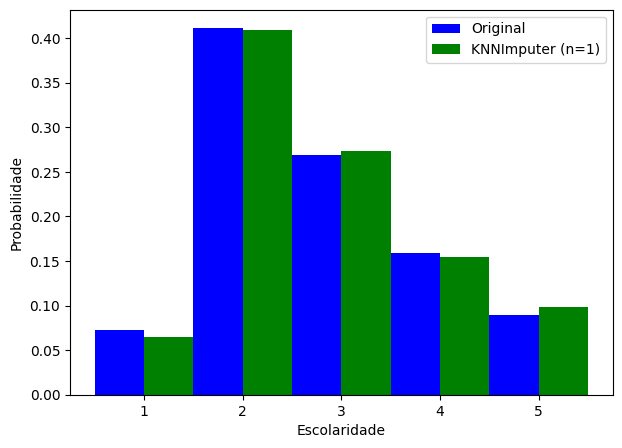

In [ ]:
x = np.sort(escolari.ESCOLARI.unique())
inic = escolari.ESCOLARI.value_counts().sort_index().values/escolari.shape[0]
knn1 = df_pulm.ESCOLARI_PREENCH.value_counts().sort_index().values/df_pulm.shape[0]

plt.figure(figsize=(7, 5))
plt.bar(x - 0.25, inic, color = 'b', width = 0.5, label='Original')
plt.bar(x + 0.25, knn1, color = 'g', width = 0.5, label='KNNImputer (n=1)')
plt.ylabel("Probabilidade")
plt.xlabel("Escolaridade")
plt.legend()

plt.show()

In [ ]:
from scipy.stats import ks_2samp

# Realize o teste de Kolmogorov-Smirnov
statistic, p_value = ks_2samp(escolari.ESCOLARI, df_pulm.ESCOLARI_PREENCH)

# Exiba o resultado do teste
print('Estatística de teste:', statistic)
print('p-value:', p_value)

# Verifique se a diferença entre as distribuições é significativa
alpha = 0.05
if p_value > alpha:
    print('\nNão há evidências para rejeitar a hipótese nula (as distribuições são similares)')
else:
    print('\nRejeitamos a hipótese nula (as distribuições são diferentes)')

Estatística de teste: 0.009976553122363396
p-value: 0.04763441901895826

Rejeitamos a hipótese nula (as distribuições são diferentes)


# **Data Exploration**

Initial analysis process to understand the structure, distribution, and patterns within the data.

## **Data**

In [ ]:
# Pulmão
!gdown 1vqYdyN9E9mV1MRTIcKJxzImpl8NRgoCt --quiet

In [ ]:
df = pd.read_csv('pulmao.csv')
print(df.shape)
df.head(3)

(45729, 50)


,INSTITU,ESCOLARI,IDADE,SEXO,IBGE,CATEATEND,DIAGPREV,TOPO,MORFO,EC,...,PRESENCA_META,PRESENCA_REC,obito_geral,obito_cancer,sobrevida_ano1,sobrevida_ano2,sobrevida_ano3,sobrevida_ano4,sobrevida_ano5,meses_diag
0,612374,2,51,2,3550308,2,2,C341,81403,IV,...,1,0,1,1,0,0,0,0,0,5
1,8,9,56,2,3548708,1,1,C342,83233,IB,...,0,0,0,0,1,1,1,1,1,61
2,8,9,53,1,3550308,9,2,C341,81403,IIIB,...,0,0,0,0,1,1,1,1,1,61


In [ ]:
df.columns

Index(['INSTITU', 'ESCOLARI', 'IDADE', 'SEXO', 'IBGE', 'CATEATEND', 'DIAGPREV',
       'TOPO', 'MORFO', 'EC', 'ECGRUP', 'NENHUM', 'CIRURGIA', 'RADIO',
       'QUIMIO', 'IMUNO', 'OUTROS', 'NENHUMAPOS', 'CIRURAPOS', 'RADIOAPOS',
       'QUIMIOAPOS', 'IMUNOAPOS', 'OUTROAPOS', 'ULTINFO', 'CONSDIAG',
       'TRATCONS', 'DIAGTRAT', 'ANODIAG', 'DRS', 'RRAS', 'DSCINST', 'IBGEATEN',
       'HABILIT2', 'DRS_INST', 'RRAS_INST', 'ECGRUP_CAT', 'ULTIDIAG',
       'CONSDIAG_CAT', 'TRATCONS_CAT', 'DIAGTRAT_CAT', 'PRESENCA_META',
       'PRESENCA_REC', 'obito_geral', 'obito_cancer', 'sobrevida_ano1',
       'sobrevida_ano2', 'sobrevida_ano3', 'sobrevida_ano4', 'sobrevida_ano5',
       'meses_diag'],
      dtype='object')

### **Cases and deaths**

In [ ]:
# Exclude patients with morphology ending in 2
df_pulm = df[~df['MORFO'].astype(str).str.endswith('2')]

# Exclude patients with morphology starting with 9
df_pulm = df_pulm[~df_pulm.MORFO.isin([90703])]

df_pulm.shape

(45719, 50)

In [ ]:
# --- Calculate total cases per diagnosis year ---
# Extract 'ANODIAG' column, count occurrences per year, and sort by year index
ano = df_pulm.ANODIAG.value_counts().sort_index()

# Convert Series to DataFrame for structural consistency
ano = pd.DataFrame(ano)

# --- Add death counts to the DataFrame ---
# Calculate total deaths by grouping by diagnosis year and summing 'obito_geral' (death indicator)
# The index alignment ensures matching with existing 'ano' index
ano['obito'] = df_pulm.groupby('ANODIAG').obito_geral.sum()
ano

,count,obito
ANODIAG,,
2000,1382,1248
2001,1366,1257
2002,1471,1369
2003,1571,1446
2004,1693,1552
2005,1809,1641
2006,1631,1510
2007,1569,1425
2008,1722,1572


In [ ]:
# Import Plotly's graph objects module for advanced visualizations
import plotly.graph_objects as go

# Initialize a blank Figure object
fig = go.Figure()

# Background layer: Total cases (with reduced opacity for visibility)
fig.add_trace(go.Bar(
    x=ano.index,                     # Diagnosis years on x-axis
    y=ano['count'],                  # Total case counts on y-axis
    name="Total cases",              # Legend label
    marker_color='blue',             # Base color for total cases
    opacity=0.6                      # Partial transparency for overlay effect
))

# Foreground layer: Deaths (more opaque for emphasis)
fig.add_trace(go.Bar(
    x=ano.index,                     # Diagnosis years on x-axis
    y=ano['obito'],                  # Death counts on y-axis
    name="Deaths",                   # Legend label
    marker_color='red',              # Highlight color for deaths
    opacity=0.8                      # Higher opacity for visual prominence
))

# Critical layout configuration for proper overlay
fig.update_layout(
    barmode='overlay',               # Overlap bars instead of stacking
    title_text="Lung Cancer",    # Chart title
    xaxis_tickangle=-45,             # Rotate x-axis labels for readability
    xaxis=dict(
        tickmode='linear',          # Show every year
        tick0=2000,                 # First tick at year 2000
        dtick=1,                    # Tick interval = 1 year
        title_text="Year of diagnosis"  # X-axis label (fixed typo)
    ),
    yaxis=dict(
        title_text="Number of patients"  # Y-axis label
    )
)

# Display the interactive visualization
fig.show()

In [ ]:
# --- Calculate total cases per diagnosis year ---
# Extract 'ANODIAG' column, count occurrences per year, and sort by year index
ano = df_pulm.ANODIAG.value_counts().sort_index()

# Convert Series to DataFrame for structural consistency
ano = pd.DataFrame(ano)

# --- Add death y cancer counts to the DataFrame ---
# Calculate total deaths by cancer by grouping by diagnosis year and summing 'obito_cancer' (death indicator)
# The index alignment ensures matching with existing 'ano' index
ano['obito_cancer'] = df_pulm.groupby('ANODIAG').obito_cancer.sum()
ano

,count,obito_cancer
ANODIAG,,
2000,1382,1200
2001,1366,1198
2002,1471,1282
2003,1571,1330
2004,1693,1453
2005,1809,1559
2006,1631,1423
2007,1569,1356
2008,1722,1485


In [ ]:
# Import Plotly's graph objects module for advanced visualizations
import plotly.graph_objects as go

# Initialize a blank Figure object
fig = go.Figure()

# Background layer: Total cases (with reduced opacity for visibility)
fig.add_trace(go.Bar(
    x=ano.index,                     # Diagnosis years on x-axis
    y=ano['count'],                  # Total case counts on y-axis
    name="Total cases",              # Legend label
    marker_color='blue',             # Base color for total cases
    opacity=0.6                      # Partial transparency for overlay effect
))

# Foreground layer: Deaths (more opaque for emphasis)
fig.add_trace(go.Bar(
    x=ano.index,                     # Diagnosis years on x-axis
    y=ano['obito_cancer'],           # Death counts on y-axis
    name="Deaths by cancer",         # Legend label
    marker_color='red',              # Highlight color for deaths
    opacity=0.8                      # Higher opacity for visual prominence
))

# Critical layout configuration for proper overlay
fig.update_layout(
    barmode='overlay',               # Overlap bars instead of stacking
    title_text="Lung Cancer",    # Chart title
    xaxis_tickangle=-45,             # Rotate x-axis labels for readability
    xaxis=dict(
        tickmode='linear',           # Show every year
        tick0=2000,                  # First tick at year 2000
        dtick=1,                     # Tick interval = 1 year
        title_text="Year of diagnosis"  # X-axis label (fixed typo)
    ),
    yaxis=dict(
        title_text="Number of patients"  # Y-axis label
    )
)

# Display the interactive visualization
fig.show()

## **Kaplan-Meier Curves**

**Morphologies**

In [ ]:
df.MORFO_CAT.value_counts().sort_index()

In [ ]:
np.sort(df.MORFO_CAT.unique())

In [ ]:
morfos = np.sort(df.MORFO_CAT.unique())

E = (df.obito_geral == 1)
T = df.meses_diag
title = 'Lung Cancer - Morphologies'
cats = ['Small Cell', 'Non-Small Cell', 'Neuroendocrine']

kmf = KaplanMeierFitter()

fig = plt.figure(figsize=(12, 6))
ax = plt.subplot(111)

for i, morfo in enumerate(morfos):
    group = (df.MORFO_CAT == morfo)
    label = f'MORFO - {cats[i]}'

    T1=T[group]
    E1=E[group]

    ax = kmf.fit(T1, E1, label=f"{label}").plot(ax=ax, ci_show=False,
                                                show_censors=True)

ax.set_title(title)
ax.set_xlabel('Months after diagnosis')
ax.set_ylabel('Survival function')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(np.arange(0, 72, 12))
plt.ylim([0, 1.1])
plt.xlim([0, 61])
plt.show()

**Topographies**

In [ ]:
df.TOPO.value_counts().sort_index()

,count
TOPO,
C340,2499
C341,12983
C342,1340
C343,6736
C348,1679
C349,20492


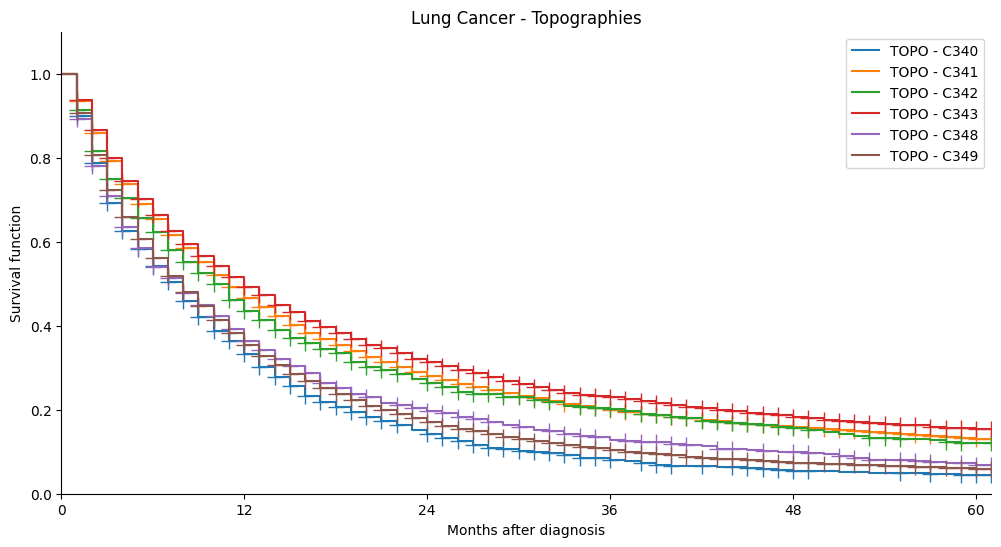

In [ ]:
topos = np.sort(df.TOPO.unique())

E = (df.obito_geral == 1)
T = df.meses_diag
title = 'Lung Cancer - Topographies'

kmf = KaplanMeierFitter()

fig = plt.figure(figsize=(12, 6))
ax = plt.subplot(111)

for topo in topos:
    group = (df.TOPO == f'{topo}')
    label = f'TOPO - {topo}'

    T1=T[group]
    E1=E[group]

    ax = kmf.fit(T1, E1, label=f"{label}").plot(ax=ax, ci_show=False,
                                                show_censors=True)

ax.set_title(title)
ax.set_xlabel('Months after diagnosis')
ax.set_ylabel('Survival function')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(np.arange(0, 72, 12))
plt.ylim([0, 1.1])
plt.xlim([0, 61])
plt.show()

**EC e Habilit2**

In [ ]:
df.ECGRUP.value_counts().sort_index()

,count
ECGRUP,
I,4938
II,2940
III,12042
IV,25809


In [ ]:
df_habilit = df[df.HABILIT2.isin([1, 2, 3])]
print(df_habilit.shape)
df_habilit.HABILIT2.value_counts().sort_index()

(43335, 50)


,count
HABILIT2,
1,11930
2,31040
3,365


In [ ]:
df_habilit.ECGRUP.value_counts().sort_index()

,count
ECGRUP,
I,4491
II,2765
III,11471
IV,24608


In [ ]:
df_ec1 = df_habilit[df_habilit.ECGRUP == 'I']
df_ec2 = df_habilit[df_habilit.ECGRUP == 'II']
df_ec3 = df_habilit[df_habilit.ECGRUP == 'III']
df_ec4 = df_habilit[df_habilit.ECGRUP == 'IV']

df_ec1.shape, df_ec2.shape, df_ec3.shape, df_ec4.shape

((4491, 50), (2765, 50), (11471, 50), (24608, 50))

log-rank p-value:
    CACON com UNACON = 5.475e-26
    CACON com Hosp. Geral = 6.763e-07



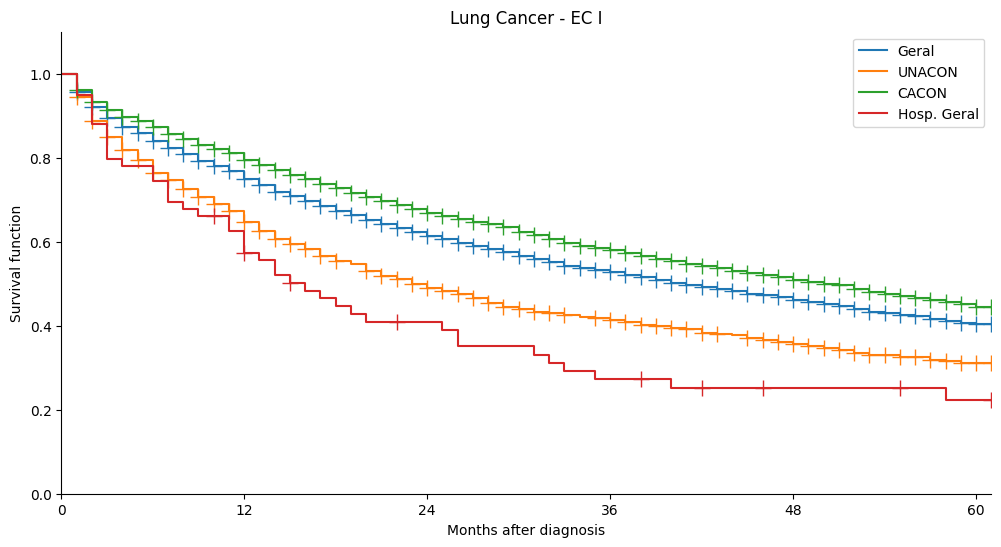

In [ ]:
data = df_ec1

E = (data.obito_geral == 1)
T = data.meses_diag
title = 'Lung Cancer - EC I'

kmf = KaplanMeierFitter()

fig = plt.figure(figsize=(12, 6))
ax = plt.subplot(111)
ax = kmf.fit(T, E, label=f'Geral').plot(ax=ax, ci_show=False, show_censors=True)

group1 = (data.HABILIT2 == 1)
label1 = 'UNACON'
T1=T[group1]
E1=E[group1]

group2 = (data.HABILIT2 == 2)
label2 = 'CACON'
T2=T[group2]
E2=E[group2]

group3 = (data.HABILIT2 == 3)
label3 = 'Hosp. Geral'
T3=T[group3]
E3=E[group3]

ax = kmf.fit(T1, E1, label=label1).plot(ax=ax, ci_show=False, show_censors=True)
ax = kmf.fit(T2, E2, label=label2).plot(ax=ax, ci_show=False, show_censors=True)
ax = kmf.fit(T3, E3, label=label3).plot(ax=ax, ci_show=False, show_censors=True)

results1 = logrank_test(T2, T1, event_observed_A=E2, event_observed_B=E1)
results2 = logrank_test(T2, T3, event_observed_A=E2, event_observed_B=E3)

ax.set_title(title)
ax.set_xlabel('Months after diagnosis')
ax.set_ylabel('Survival function')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(np.arange(0, 72, 12))
plt.ylim([0, 1.1])
plt.xlim([0, 61]);

print('log-rank p-value:')
print(f'    CACON com UNACON = {results1.p_value:.4}')
print(f'    CACON com Hosp. Geral = {results2.p_value:.4}')
print()

log-rank p-value:
    CACON com UNACON = 0.001695
    CACON com Hosp. Geral = 4.101e-14



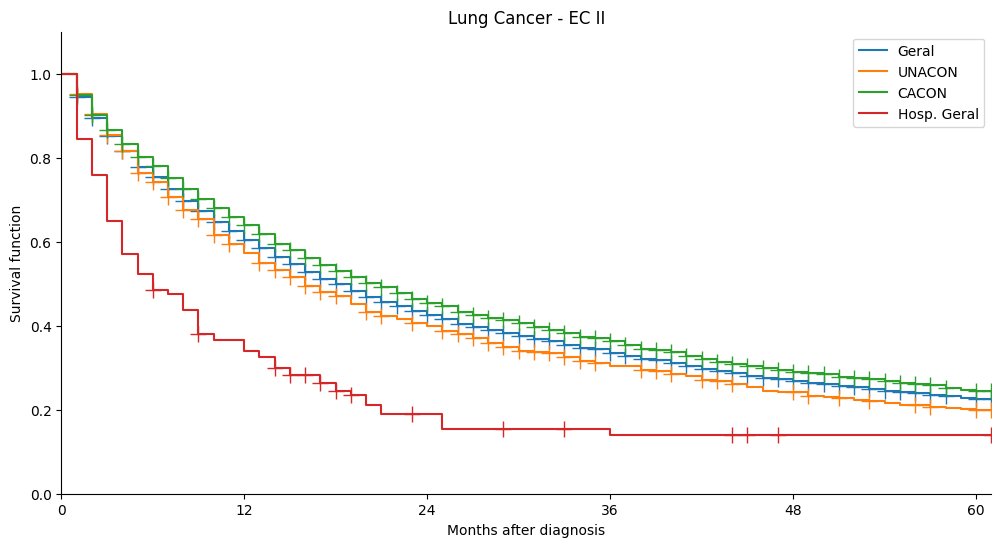

In [ ]:
data = df_ec2

E = (data.obito_geral == 1)
T = data.meses_diag
title = 'Lung Cancer - EC II'

kmf = KaplanMeierFitter()

fig = plt.figure(figsize=(12, 6))
ax = plt.subplot(111)
ax = kmf.fit(T, E, label=f'Geral').plot(ax=ax, ci_show=False, show_censors=True)

group1 = (data.HABILIT2 == 1)
label1 = 'UNACON'
T1=T[group1]
E1=E[group1]

group2 = (data.HABILIT2 == 2)
label2 = 'CACON'
T2=T[group2]
E2=E[group2]

group3 = (data.HABILIT2 == 3)
label3 = 'Hosp. Geral'
T3=T[group3]
E3=E[group3]

ax = kmf.fit(T1, E1, label=label1).plot(ax=ax, ci_show=False, show_censors=True)
ax = kmf.fit(T2, E2, label=label2).plot(ax=ax, ci_show=False, show_censors=True)
ax = kmf.fit(T3, E3, label=label3).plot(ax=ax, ci_show=False, show_censors=True)

results1 = logrank_test(T2, T1, event_observed_A=E2, event_observed_B=E1)
results2 = logrank_test(T2, T3, event_observed_A=E2, event_observed_B=E3)

ax.set_title(title)
ax.set_xlabel('Months after diagnosis')
ax.set_ylabel('Survival function')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(np.arange(0, 72, 12))
plt.ylim([0, 1.1])
plt.xlim([0, 61]);

print('log-rank p-value:')
print(f'    CACON com UNACON = {results1.p_value:.4}')
print(f'    CACON com Hosp. Geral = {results2.p_value:.4}')
print()

log-rank p-value:
    CACON com UNACON = 0.6383
    CACON com Hosp. Geral = 0.001467



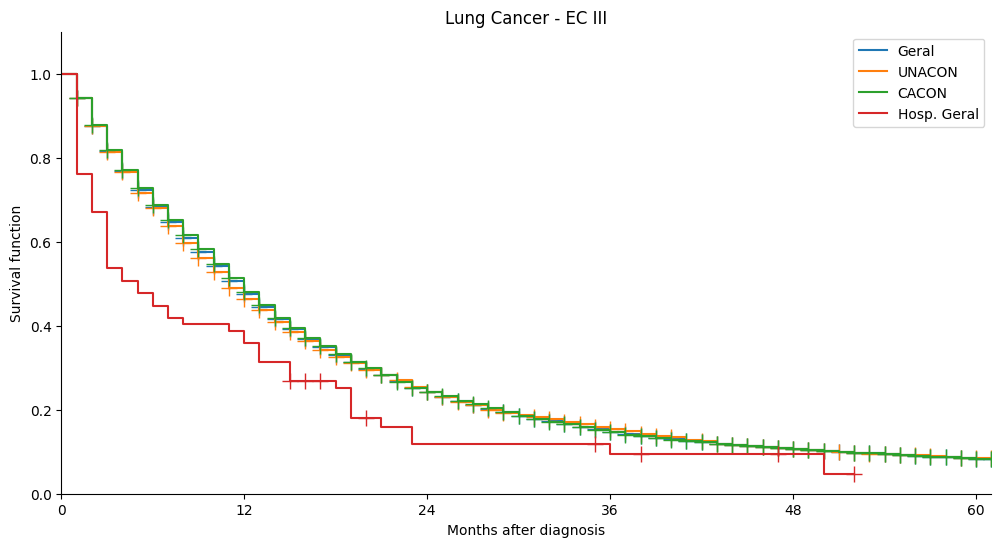

In [ ]:
data = df_ec3

E = (data.obito_geral == 1)
T = data.meses_diag
title = 'Lung Cancer - EC III'

kmf = KaplanMeierFitter()

fig = plt.figure(figsize=(12, 6))
ax = plt.subplot(111)
ax = kmf.fit(T, E, label=f'Geral').plot(ax=ax, ci_show=False, show_censors=True)

group1 = (data.HABILIT2 == 1)
label1 = 'UNACON'
T1=T[group1]
E1=E[group1]

group2 = (data.HABILIT2 == 2)
label2 = 'CACON'
T2=T[group2]
E2=E[group2]

group3 = (data.HABILIT2 == 3)
label3 = 'Hosp. Geral'
T3=T[group3]
E3=E[group3]

ax = kmf.fit(T1, E1, label=label1).plot(ax=ax, ci_show=False, show_censors=True)
ax = kmf.fit(T2, E2, label=label2).plot(ax=ax, ci_show=False, show_censors=True)
ax = kmf.fit(T3, E3, label=label3).plot(ax=ax, ci_show=False, show_censors=True)

results1 = logrank_test(T2, T1, event_observed_A=E2, event_observed_B=E1)
results2 = logrank_test(T2, T3, event_observed_A=E2, event_observed_B=E3)

ax.set_title(title)
ax.set_xlabel('Months after diagnosis')
ax.set_ylabel('Survival function')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(np.arange(0, 72, 12))
plt.ylim([0, 1.1])
plt.xlim([0, 61]);

print('log-rank p-value:')
print(f'    CACON com UNACON = {results1.p_value:.4}')
print(f'    CACON com Hosp. Geral = {results2.p_value:.4}')
print()

log-rank p-value:
    CACON com UNACON = 0.03498
    CACON com Hosp. Geral = 0.001391



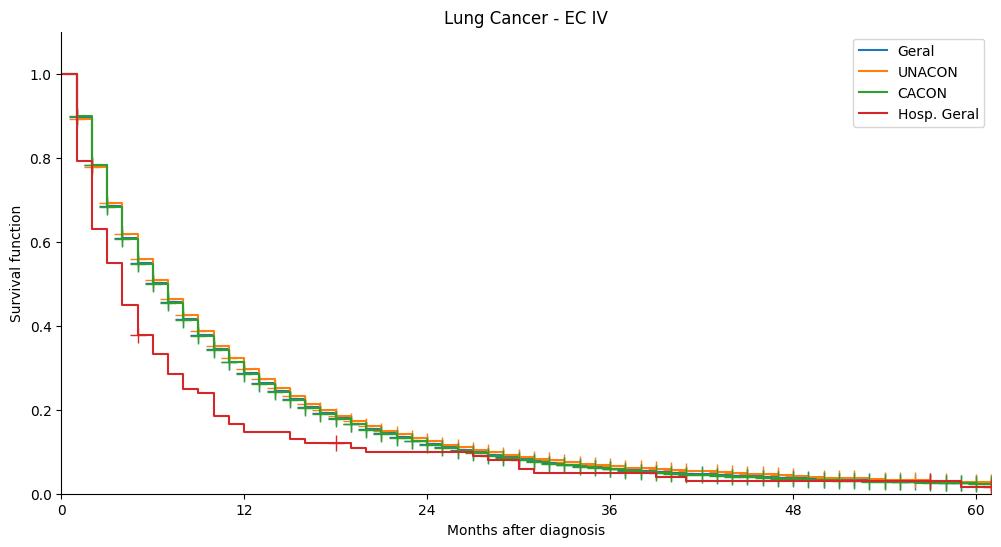

In [ ]:
data = df_ec4

E = (data.obito_geral == 1)
T = data.meses_diag
title = 'Lung Cancer - EC IV'

kmf = KaplanMeierFitter()

fig = plt.figure(figsize=(12, 6))
ax = plt.subplot(111)
ax = kmf.fit(T, E, label=f'Geral').plot(ax=ax, ci_show=False, show_censors=True)

group1 = (data.HABILIT2 == 1)
label1 = 'UNACON'
T1=T[group1]
E1=E[group1]

group2 = (data.HABILIT2 == 2)
label2 = 'CACON'
T2=T[group2]
E2=E[group2]

group3 = (data.HABILIT2 == 3)
label3 = 'Hosp. Geral'
T3=T[group3]
E3=E[group3]

ax = kmf.fit(T1, E1, label=label1).plot(ax=ax, ci_show=False, show_censors=True)
ax = kmf.fit(T2, E2, label=label2).plot(ax=ax, ci_show=False, show_censors=True)
ax = kmf.fit(T3, E3, label=label3).plot(ax=ax, ci_show=False, show_censors=True)

results1 = logrank_test(T2, T1, event_observed_A=E2, event_observed_B=E1)
results2 = logrank_test(T2, T3, event_observed_A=E2, event_observed_B=E3)

ax.set_title(title)
ax.set_xlabel('Months after diagnosis')
ax.set_ylabel('Survival function')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(np.arange(0, 72, 12))
plt.ylim([0, 1.1])
plt.xlim([0, 61]);

print('log-rank p-value:')
print(f'    CACON com UNACON = {results1.p_value:.4}')
print(f'    CACON com Hosp. Geral = {results2.p_value:.4}')
print()

**DRS**

In [ ]:
df.DRS.value_counts().sort_index()

,count
DRS,
1,21241
2,1053
3,1271
4,855
5,1303
6,2888
7,3293
8,798
9,1526


In [ ]:
results_drs = pd.DataFrame(columns=['DRS', 'Total', 'Inicial', 'Avançado',
                                    'mean', 'min', '25%', '50%', '75%', 'max'])

list_drs = np.sort(df.DRS.unique())

for n_drs in list_drs:

    df_drs = df[df.DRS == n_drs]

    n = df_drs.shape[0]
    ini = df_drs.ECGRUP_CAT.value_counts(normalize=True).sort_index()['Inicial']
    avanc = df_drs.ECGRUP_CAT.value_counts(normalize=True).sort_index()['Avançado']

    E = (df_drs.obito_geral == 1)
    T = df_drs.meses_diag

    kmf = KaplanMeierFitter()

    surv_info = kmf.fit(T, E).survival_function_.describe().T[['mean', 'min', '25%', '50%', '75%', 'max']].values[0]

    new = {'DRS': n_drs, 'Total': n, 'Inicial': ini, 'Avançado': avanc,
           'mean': surv_info[0], 'min': surv_info[1], '25%': surv_info[2],
           '50%': surv_info[3], '75%': surv_info[4], 'max': surv_info[5]}

    results_drs = pd.concat([results_drs, pd.DataFrame([new])], ignore_index=True)

results_drs

<ipython-input-29-e86d80c466bc>:25: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



,DRS,Total,Inicial,Avançado,mean,min,25%,50%,75%,max
0,1,21241,0.188833,0.811167,0.281643,0.101255,0.129338,0.189000,0.348529,1.0
1,2,1053,0.122507,0.877493,0.275198,0.093068,0.120311,0.170178,0.340979,1.0
2,3,1271,0.131393,0.868607,0.253439,0.080321,0.100790,0.149069,0.319210,1.0
3,4,855,0.214035,0.785965,0.373139,0.161945,0.207206,0.291908,0.467074,1.0
4,5,1303,0.115119,0.884881,0.252126,0.089998,0.106277,0.167740,0.309232,1.0
5,6,2888,0.154432,0.845568,0.233122,0.062755,0.088539,0.131530,0.281213,1.0
6,7,3293,0.145460,0.854540,0.286712,0.097949,0.129780,0.184253,0.366545,1.0
7,8,798,0.120301,0.879699,0.256663,0.070905,0.094321,0.171275,0.321617,1.0
8,9,1526,0.250328,0.749672,0.272744,0.084032,0.112374,0.174244,0.350669,1.0
9,10,1646,0.181045,0.818955,0.287131,0.100636,0.131600,0.183063,0.356934,1.0


In [ ]:
def plot_km_drs(df, n_drs):

    data = df[df.DRS == n_drs]

    E = (data.obito_geral == 1)
    T = data.meses_diag
    title = f'Lung Cancer - DRS {n_drs}'

    kmf = KaplanMeierFitter()

    fig = plt.figure(figsize=(12, 6))
    ax = plt.subplot(111)
    ax = kmf.fit(T, E, #label=f'DRS {n_drs}'
    ).plot(ax=ax, ci_show=False, show_censors=True)

    ax.set_title(title)
    ax.set_xlabel('Months after diagnosis')
    ax.set_ylabel('Survival function')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.xticks(np.arange(0, 72, 12))
    plt.ylim([0, 1.1])
    plt.xlim([0, 61]);

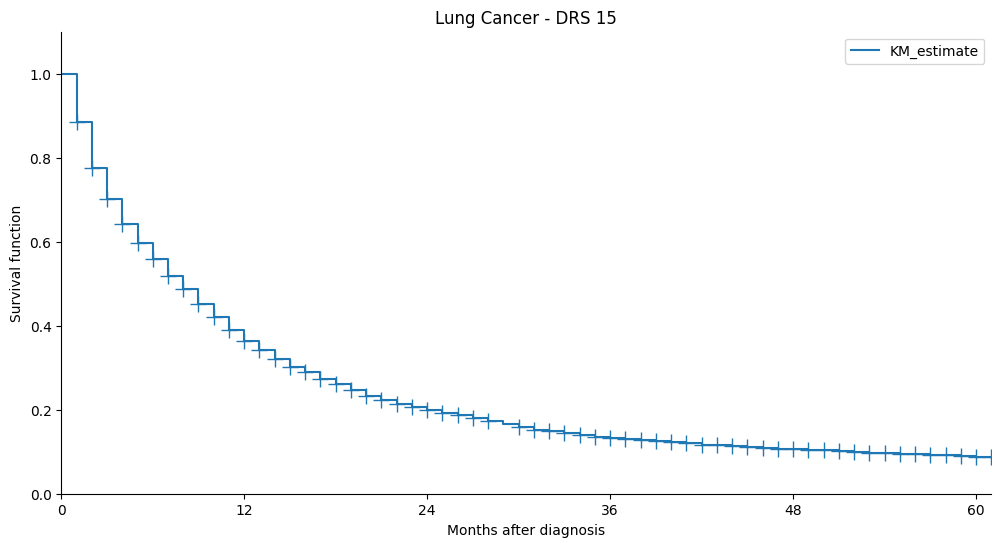

In [ ]:
plot_km_drs(df, 15)

In [ ]:
results_drs.to_csv('results_drs.csv', index=False)

**RRAS**

In [ ]:
df.RRAS.value_counts().sort_index()

,count
RRAS,
RRAS 01,1869
RRAS 02,1325
RRAS 03,343
RRAS 04,1081
RRAS 05,1607
RRAS 06,15016
RRAS 07,960
RRAS 08,1239
RRAS 09,2888


In [ ]:
results_rras = pd.DataFrame(columns=['RRAS', 'Total', 'Inicial', 'Avançado',
                                     'mean', 'min', '25%', '50%', '75%', 'max'])

list_rras = np.sort(df.RRAS.unique())

for n_rras in list_rras:

    df_rras = df[df.RRAS == n_rras]

    n = df_rras.shape[0]
    ini = df_rras.ECGRUP_CAT.value_counts(normalize=True).sort_index()['Inicial']
    avanc = df_rras.ECGRUP_CAT.value_counts(normalize=True).sort_index()['Avançado']

    E = (df_rras.obito_geral == 1)
    T = df_rras.meses_diag

    kmf = KaplanMeierFitter()

    surv_info = kmf.fit(T, E).survival_function_.describe().T[['mean', 'min', '25%', '50%', '75%', 'max']].values[0]

    new = {'RRAS': n_rras, 'Total': n, 'Inicial': ini, 'Avançado': avanc,
           'mean': surv_info[0], 'min': surv_info[1], '25%': surv_info[2],
           '50%': surv_info[3], '75%': surv_info[4], 'max': surv_info[5]}

    results_rras = pd.concat([results_rras, pd.DataFrame([new])], ignore_index=True)

results_rras

<ipython-input-33-68d33fdc660c>:25: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



,RRAS,Total,Inicial,Avançado,mean,min,25%,50%,75%,max
0,RRAS 01,1869,0.239700,0.760300,0.310831,0.119891,0.151215,0.215198,0.385601,1.0
1,RRAS 02,1325,0.181132,0.818868,0.295069,0.102671,0.134254,0.205821,0.369769,1.0
2,RRAS 03,343,0.163265,0.836735,0.318590,0.097989,0.149823,0.238005,0.405951,1.0
3,RRAS 04,1081,0.163737,0.836263,0.260003,0.081887,0.105947,0.164252,0.325409,1.0
4,RRAS 05,1607,0.147480,0.852520,0.269944,0.082115,0.110717,0.173749,0.342718,1.0
5,RRAS 06,15016,0.189997,0.810003,0.281829,0.102366,0.131063,0.190426,0.347507,1.0
6,RRAS 07,960,0.208333,0.791667,0.357890,0.151383,0.191585,0.274192,0.449844,1.0
7,RRAS 08,1239,0.165456,0.834544,0.297062,0.108314,0.136114,0.196413,0.378512,1.0
8,RRAS 09,2888,0.154432,0.845568,0.233122,0.062755,0.088539,0.131530,0.281213,1.0
9,RRAS 10,1526,0.250328,0.749672,0.272744,0.084032,0.112374,0.174244,0.350669,1.0


In [ ]:
def plot_km_rras(df, n_rras):

    data = df[df.RRAS == n_rras]

    E = (data.obito_geral == 1)
    T = data.meses_diag
    title = f'Lung Cancer - {n_rras}'

    kmf = KaplanMeierFitter()

    fig = plt.figure(figsize=(12, 6))
    ax = plt.subplot(111)
    ax = kmf.fit(T, E).plot(ax=ax, ci_show=False, show_censors=True)

    ax.set_title(title)
    ax.set_xlabel('Months after diagnosis')
    ax.set_ylabel('Survival function')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.xticks(np.arange(0, 72, 12))
    plt.ylim([0, 1.1])
    plt.xlim([0, 61]);

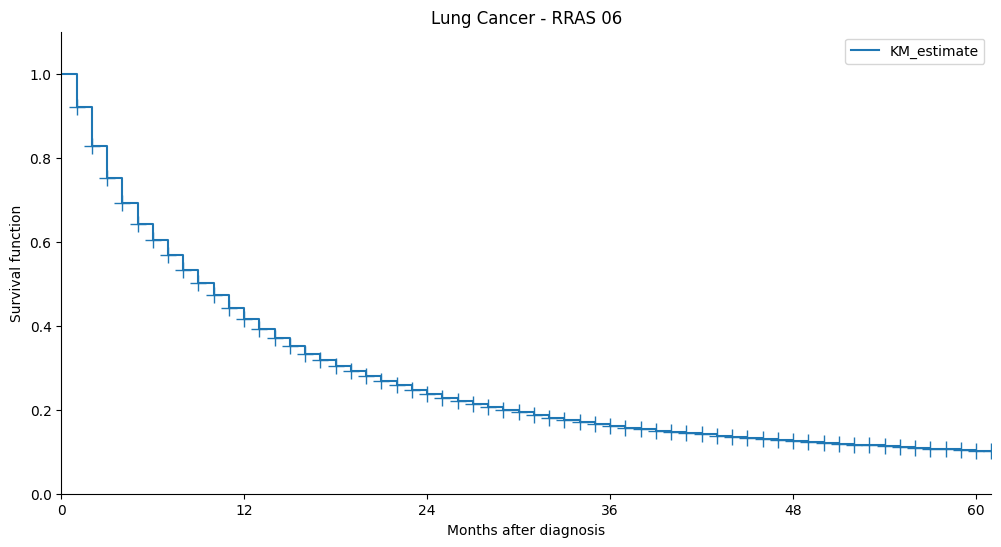

In [ ]:
plot_km_rras(df, 'RRAS 06')

In [ ]:
results_rras.to_csv('results_rras.csv', index=False)

# **Old Data Preparation**

In [ ]:
!gdown 1B1qBKob6l-JCOazIko4V6cjK1mIxn2D1 --quiet

In [ ]:
df = pd.read_csv('pacigeral_12_23.csv')
print(df.shape)
df.head(3)

In [ ]:
# from dateutil.relativedelta import relativedelta

In [ ]:
def preparing_dataset(df):
    """
    Prepara o conjunto de dados para análise, aplicando filtros e transformações necessárias.

    Parâmetros:
    -----------
    df : pandas.DataFrame
        O conjunto de dados que será preparado.

    Retorno:
    --------
    pandas.DataFrame
        O conjunto de dados após as transformações.
    """

    df_aux = df.copy()

    # Topografia de Pulmão (C34)
    df_aux = df_aux[df_aux.TOPOGRUP == 'C34']

    # Somente residentes do estado de SP
    df_aux = df_aux[df_aux.UFRESID == 'SP']

    # Somente com confirmação microscópica
    df_aux = df_aux[df_aux.BASEDIAG == 3]

    # ECGRUP sem 0, X e Y
    df_aux = df_aux[~df_aux.ECGRUP.isin(['0','X','Y'])]

    # Não fez HORMONIO
    df_aux = df_aux[df_aux.HORMONIO == 0]

    # Não fez TMO
    df_aux = df_aux[df_aux.TMO == 0]

    # Não fez HORMONIO após entrada no hospital
    df_aux = df_aux[df_aux.HORMOAPOS == 0]

    # ANODIAG até 2019
    df_aux = df_aux[df_aux.ANODIAG < 2020]

    # FAIXAETAR sem 0 a 9 e 10 a 19
    df_aux = df_aux[~df_aux.FAIXAETAR.isin(['00-09', '10-19'])]

    # Tratamento das colunas com datas
    list_datas = ['DTCONSULT', 'DTDIAG', 'DTTRAT', 'DTULTINFO']

    for col_data in list_datas:
        df_aux[col_data] = pd.to_datetime(df_aux[col_data])

    df_aux['CONSDIAG'] = (df_aux.DTDIAG - df_aux.DTCONSULT).dt.days
    df_aux['DIAGTRAT'] = (df_aux.DTTRAT - df_aux.DTDIAG).dt.days
    df_aux['TRATCONS'] = (df_aux.DTTRAT - df_aux.DTCONSULT).dt.days
    df_aux['ULTIDIAG'] = (df_aux.DTULTINFO - df_aux.DTDIAG).dt.days
    # df_aux['ULTIDIAG_M'] = (df_aux.DTULTINFO - df_aux.DTDIAG).dt.months

    # # Função que calcula a diferença em meses
    # df_aux['ULTIDIAG_M'] = df_aux.apply(lambda row: relativedelta(row['DTULTINFO'], row['DTDIAG']).months +
    #                                     12 * (relativedelta(row['DTULTINFO'], row['DTDIAG']).years), axis=1)

    df_aux[['DIAGTRAT', 'TRATCONS']] = df_aux[['DIAGTRAT', 'TRATCONS']].fillna(-1)

    df_aux['CONSDIAG_CAT'] = [0 if consdiag <= 30 else 1 if consdiag <= 60 else 2 for consdiag in df_aux.CONSDIAG]
    df_aux['TRATCONS_CAT'] = [3 if tratcons < 0 else 0 if tratcons <= 60 else 1 if tratcons <= 90 else 2 for tratcons in df_aux.TRATCONS]
    df_aux['DIAGTRAT_CAT'] = [3 if diagtrat < 0 else 0 if diagtrat <= 60 else 1 if diagtrat <= 90 else 2 for diagtrat in df_aux.DIAGTRAT]

    # # Input da ESCOLARI usando ECGRUP, IDADE e SEXO
    # cols_input = ['ESCOLARI', 'IDADE', 'ECGRUP', 'SEXO']

    # df_esc = df_aux[cols_input].copy()
    # df_esc.loc[df_esc.ESCOLARI == 9, 'ESCOLARI'] = np.nan
    # df_esc.loc[df_esc.ECGRUP == 'I', 'ECGRUP'] = 1
    # df_esc.loc[df_esc.ECGRUP == 'II', 'ECGRUP'] = 2
    # df_esc.loc[df_esc.ECGRUP == 'III', 'ECGRUP'] = 3
    # df_esc.loc[df_esc.ECGRUP == 'IV', 'ECGRUP'] = 4

    # X = df_esc.values
    # imputer = KNNImputer(n_neighbors=3, weights='distance')
    # df_aux['ESCOLARI_preench'] = imputer.fit_transform(X)[:,0].round()

    # Pegando somente o número da DRS
    DRS_expand = df_aux.DRS.str.split(' ', expand=True)
    df_aux['DRS'] = DRS_expand[1]

    # Criação da coluna de presença de metástase
    df_aux['PRESENCA_META'] = 0
    df_aux.loc[df_aux.META01.notnull(), 'PRESENCA_META'] = 1

    # Variável para presença de recidiva (0 = Não, 1 = Sim)
    df_aux['PRESENCA_REC'] = [0 if rec == 1 else 1 for rec in df_aux.RECNENHUM]
    df_aux.loc[(df_aux.PRESENCA_REC == 0) & (df_aux.DTRECIDIVA.notnull()), 'PRESENCA_REC'] = 1

    # Retirada das colunas que não serão usadas
    cols = df_aux.columns
    drop_cols = ['UFNASC', 'UFRESID', 'CIDADE', 'DTCONSULT', 'CLINICA', 'DTDIAG',
                 'BASEDIAG', 'TOPOGRUP', 'DESCTOPO', 'DESCMORFO', 'T', 'N', 'M',
                 'PT', 'PN', 'PM', 'S', 'G', 'LOCALTNM', 'IDMITOTIC', 'PSA',
                 'GLEASON', 'OUTRACLA', 'META01', 'META02', 'META03', 'META04',
                 'DTTRAT', 'NAOTRAT', 'TRATAMENTO', 'TRATHOSP', 'TRATFANTES',
                 'TRATFAPOS', 'HORMONIO', 'TMO', 'NENHUMANT', 'CIRURANT', 'RADIOANT',
                 'QUIMIOANT', 'HORMOANT', 'TMOANT', 'IMUNOANT', 'OUTROANT',
                 'HORMOAPOS', 'TMOAPOS', 'DTULTINFO', 'CICI', 'CICIGRUP', 'CICISUBGRU',
                 'FAIXAETAR', 'LATERALI', 'INSTORIG', 'RRAS', 'ERRO', 'DTRECIDIVA',
                 'RECNENHUM', 'RECLOCAL', 'RECREGIO', 'RECDIST', 'REC01', 'REC02',
                 'REC03', 'REC04', 'CIDO', 'DSCCIDO', 'HABILIT', 'HABIT11',
                 'HABILIT1', 'CIDADEH', 'PERDASEG']

    cols = cols.drop(drop_cols)

    return df_aux[cols]

################################################################################

def get_labels(df):
    """
    Cria novas colunas para indicar se o paciente morreu, se morreu devido a câncer e se está vivo após 1, 3 e 5 anos
    a partir do diagnóstico.

    Parâmetros:
    -----------
    df : pandas.DataFrame
        DataFrame contendo os dados dos pacientes.

    Retorno:
    --------
    pandas.DataFrame
        DataFrame com as novas colunas adicionadas.

    """

    df_aux = df.copy()

    df_aux['obito_geral'] = 0
    df_aux['obito_cancer'] = 0

    df_aux['sobrevida_ano1'] = 0
    df_aux['sobrevida_ano2'] = 0
    df_aux['sobrevida_ano3'] = 0
    df_aux['sobrevida_ano4'] = 0
    df_aux['sobrevida_ano5'] = 0

    df_aux.loc[df_aux.ULTINFO > 2, 'obito_geral'] = 1

    df_aux.loc[df_aux.ULTINFO == 3, 'obito_cancer'] = 1

    df_aux.loc[df_aux.ULTIDIAG > 365.25, 'sobrevida_ano1'] = 1
    df_aux.loc[df_aux.ULTIDIAG > 2*365.25, 'sobrevida_ano2'] = 1
    df_aux.loc[df_aux.ULTIDIAG > 3*365.25, 'sobrevida_ano3'] = 1
    df_aux.loc[df_aux.ULTIDIAG > 4*365.25, 'sobrevida_ano4'] = 1
    df_aux.loc[df_aux.ULTIDIAG > 5*365.25, 'sobrevida_ano5'] = 1

    return df_aux

In [ ]:
teste = preparing_dataset(df)
teste.shape

In [ ]:
teste.columns

**Morfologia**

In [ ]:
teste[teste['MORFO'].astype(str).str.endswith('2')].MORFO.value_counts()

In [ ]:
# Substituir o último dígito das linhas em que o último dígito é 2 por 3
teste['MORFO'] = teste['MORFO'].astype(str).apply(lambda x: int(x[:-1] + '3') if x[-1] == '2' else int(x))

teste[teste['MORFO'].astype(str).str.endswith('2')].MORFO.value_counts()

In [ ]:
np.sort(teste.MORFO.unique())

In [ ]:
teste[teste['MORFO'].astype(str).str.endswith('1')].MORFO.value_counts()

In [ ]:
peq_cel = [80133, 80413, 80423, 80433, 80443, 80453, 82403, 82493] # Carcinomas de pequenas células

n_peq_cel = [80103, 80123, 80303, 80463, 80503, 80703, 80713, 80723, 80733,
             80783, 80833, 81403, 81443, 82003, 82303, 82503, 82513, 82523,
             82533, 82543, 82553, 82603, 83333, 84303, 84803, 84813, 85503,
             85603, 85623,
             80203] ## Carcinoma Indiferenciado
             # Carcinomas de não pequenas células
             ### 82633

neuro = [82463] # Carcinoma Neuroendócrino

tirar = [80143, 80213, 80333, 80343, 80513, 80523, 80743, 80753, 80763, 80843,
         81303, 81413, 81473, 81903, 82013, 82113, 82313, 82423, 82443, 82623,
         82633, 83103, 83233, 84013, 84403, 84603, 84703, 84903, 85203, 85513,
         85703, 85713, 85743, 85753, 86403, 89413, 80823, 80223, 80313, 80323,
         89723, 89803, 90703, 90713, 91103]

teste[teste.MORFO.isin(tirar)].shape

In [ ]:
teste[teste.MORFO.isin(tirar)]['MORFO'].value_counts().sort_index()

In [ ]:
df_morfo = teste[~teste.MORFO.isin(tirar)]
df_morfo.shape

In [ ]:
df_morf = df_morfo.copy()
df_morf['MORFO_CAT'] = [0 if m in peq_cel else 1 if m in n_peq_cel else 2 for m in df_morf.MORFO]
df_morf['MORFO_CAT'].value_counts(normalize=True).sort_index()

In [ ]:
df_morf[df_morf.MORFO_CAT == 2]['MORFO'].unique()

In [ ]:
teste = df_morf.copy()
teste.shape

In [ ]:
teste.isna().sum().sort_values(ascending=False).head(3)

In [ ]:
teste = get_labels(teste)
teste.shape

## **Input Escolaridade**

In [ ]:
teste.ESCOLARI.value_counts().sort_index()

In [ ]:
teste.ESCOLARI.value_counts(normalize=True).sort_index()

In [ ]:
escolari = teste[teste.ESCOLARI != 9]
escolari.ESCOLARI.value_counts().sort_index()

**KNNImputer**

In [ ]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler

# Input da ESCOLARI usando ECGRUP, IDADE e SEXO
cols_input = ['ESCOLARI', 'IDADE', 'ECGRUP', 'MORFO_CAT', 'CATEATEND']

df_esc = teste[cols_input].copy()
df_esc.loc[df_esc.ESCOLARI == 9, 'ESCOLARI'] = np.nan
df_esc.loc[df_esc.ECGRUP == 'I', 'ECGRUP'] = 1
df_esc.loc[df_esc.ECGRUP == 'II', 'ECGRUP'] = 2
df_esc.loc[df_esc.ECGRUP == 'III', 'ECGRUP'] = 3
df_esc.loc[df_esc.ECGRUP == 'IV', 'ECGRUP'] = 4

X = df_esc.values
mms = MinMaxScaler()
X[:, 1:] = mms.fit_transform(X[:, 1:])

imputer = KNNImputer(n_neighbors=1, weights='distance')
teste['ESCOLARI_PREENCH'] = imputer.fit_transform(X)[:,0].round()

teste.ESCOLARI_PREENCH.value_counts().sort_index()

In [ ]:
x = np.sort(escolari.ESCOLARI.unique())
inic = escolari.ESCOLARI.value_counts().sort_index().values/escolari.shape[0]
knn1 = teste.ESCOLARI_PREENCH.value_counts().sort_index().values/teste.shape[0]

plt.figure(figsize=(7, 5))
plt.bar(x - 0.25, inic, color = 'b', width = 0.5, label='Original')
plt.bar(x + 0.25, knn1, color = 'g', width = 0.5, label='KNNImputer (n=1)')
plt.ylabel("Probabilidade")
plt.xlabel("Escolaridade")
plt.legend()

plt.show()

In [ ]:
from scipy.stats import ks_2samp

# Realize o teste de Kolmogorov-Smirnov
statistic, p_value = ks_2samp(escolari.ESCOLARI, teste.ESCOLARI_PREENCH)

# Exiba o resultado do teste
print('Estatística de teste:', statistic)
print('p-value:', p_value)

# Verifique se a diferença entre as distribuições é significativa
alpha = 0.05
if p_value > alpha:
    print('\nNão há evidências para rejeitar a hipótese nula (as distribuições são similares)')
else:
    print('\nRejeitamos a hipótese nula (as distribuições são diferentes)')

## **Saídas**

In [ ]:
teste.obito_geral.value_counts()

In [ ]:
teste.obito_cancer.value_counts()

In [ ]:
ano1 = teste[~((teste.obito_geral == 0) & (teste.sobrevida_ano1 == 0))]
print(ano1.shape)
ano1.sobrevida_ano1.value_counts()

In [ ]:
ano2 = teste[~((teste.obito_geral == 0) & (teste.sobrevida_ano2 == 0))]
print(ano2.shape)
ano2.sobrevida_ano2.value_counts()

In [ ]:
ano3 = teste[~((teste.obito_geral == 0) & (teste.sobrevida_ano3 == 0))]
print(ano3.shape)
ano3.sobrevida_ano3.value_counts()

In [ ]:
ano4 = teste[~((teste.obito_geral == 0) & (teste.sobrevida_ano4 == 0))]
print(ano4.shape)
ano4.sobrevida_ano4.value_counts()

In [ ]:
ano5 = teste[~((teste.obito_geral == 0) & (teste.sobrevida_ano5 == 0))]
print(ano5.shape)
ano5.sobrevida_ano5.value_counts()

In [ ]:
teste.to_csv('/content/drive/MyDrive/Trabalho/Cancer/Pulmão/Datasets/pulmao_labels.csv',
             index=False)

## **Informações**

In [ ]:
!gdown 1HMFWuCBmCQDfv6aml6tzl7YehNIWhbrV --quiet

In [ ]:
df = pd.read_csv('pulmao_labels.csv')
print(df.shape)
df.head(3)

In [ ]:
df.columns

In [ ]:
df.ESCOLARI.value_counts().sort_index()

In [ ]:
(df.IDADE >= 60).sum()

In [ ]:
(df.IDADE < 60).sum()

In [ ]:
df.SEXO.value_counts().sort_index()

In [ ]:
df.CATEATEND.value_counts().sort_index()

In [ ]:
df.DIAGPREV.value_counts().sort_index()

In [ ]:
df.TOPO.value_counts().sort_index()

In [ ]:
df.MORFO_CAT.value_counts().sort_index()

In [ ]:
df.EC.value_counts().sort_index()

In [ ]:
df.ECGRUP.value_counts().sort_index()

In [ ]:
df.NENHUM.value_counts().sort_index()

In [ ]:
df.CIRURGIA.value_counts().sort_index()

In [ ]:
df.RADIO.value_counts().sort_index()

In [ ]:
df.QUIMIO.value_counts().sort_index()

In [ ]:
df.IMUNO.value_counts().sort_index()

In [ ]:
df.OUTROS.value_counts().sort_index()

In [ ]:
df.NENHUMAPOS.value_counts().sort_index()

In [ ]:
df.CIRURAPOS.value_counts().sort_index()

In [ ]:
df.RADIOAPOS.value_counts().sort_index()

In [ ]:
df.QUIMIOAPOS.value_counts().sort_index()

In [ ]:
df.IMUNOAPOS.value_counts().sort_index()

In [ ]:
df.OUTROAPOS.value_counts().sort_index()

In [ ]:
df.ULTINFO.value_counts().sort_index()

In [ ]:
df.CONSDIAG.value_counts()

In [ ]:
df.TRATCONS.value_counts().sort_index()

In [ ]:
df.DIAGTRAT.value_counts().sort_index()

In [ ]:
df.ANODIAG.value_counts().sort_index()

In [ ]:
df.DRS.value_counts(dropna=False).sort_index()

In [ ]:
df.HABILIT2.value_counts().sort_index()

In [ ]:
df.PRESENCA_META.value_counts().sort_index()

In [ ]:
df.PRESENCA_REC.value_counts().sort_index()

In [ ]:
df.ESCOLARI_PREENCH.value_counts().sort_index()

In [ ]:
df.obito_geral.value_counts()

In [ ]:
df.obito_cancer.value_counts()

In [ ]:
ano1 = df[~((df.obito_geral == 0) & (df.sobrevida_ano1 == 0))]
print(ano1.shape)
ano1.sobrevida_ano1.value_counts()

In [ ]:
ano2 = df[~((df.obito_geral == 0) & (df.sobrevida_ano2 == 0))]
print(ano2.shape)
ano2.sobrevida_ano2.value_counts()

In [ ]:
ano3 = df[~((df.obito_geral == 0) & (df.sobrevida_ano3 == 0))]
print(ano3.shape)
ano3.sobrevida_ano3.value_counts()

In [ ]:
ano4 = df[~((df.obito_geral == 0) & (df.sobrevida_ano4 == 0))]
print(ano4.shape)
ano4.sobrevida_ano4.value_counts()

In [ ]:
ano5 = df[~((df.obito_geral == 0) & (df.sobrevida_ano5 == 0))]
print(ano5.shape)
ano5.sobrevida_ano5.value_counts()

## **Testes Input Escolaridade**

In [ ]:
teste.ESCOLARI.value_counts().sort_index()

In [ ]:
teste.ESCOLARI.value_counts(normalize=True).sort_index()

In [ ]:
escolari = teste[teste.ESCOLARI != 9]
escolari.ESCOLARI.value_counts().sort_index()

**KNNImputer**

In [ ]:
from sklearn.impute import KNNImputer

# Input da ESCOLARI usando ECGRUP, IDADE e SEXO
cols_input = ['ESCOLARI', 'IDADE', 'ECGRUP', 'SEXO']

df_esc = teste[cols_input].copy()
df_esc.loc[df_esc.ESCOLARI == 9, 'ESCOLARI'] = np.nan
df_esc.loc[df_esc.ECGRUP == 'I', 'ECGRUP'] = 1
df_esc.loc[df_esc.ECGRUP == 'II', 'ECGRUP'] = 2
df_esc.loc[df_esc.ECGRUP == 'III', 'ECGRUP'] = 3
df_esc.loc[df_esc.ECGRUP == 'IV', 'ECGRUP'] = 4

X = df_esc.values
for i in [1, 3, 5]:
    imputer = KNNImputer(n_neighbors=i, weights='distance')
    teste[f'ESCOLARI_{i}'] = imputer.fit_transform(X)[:,0].round()

In [ ]:
teste.ESCOLARI_1.value_counts().sort_index()

In [ ]:
x = np.sort(escolari.ESCOLARI.unique())
inic = escolari.ESCOLARI.value_counts().sort_index().values/escolari.shape[0]
knn1 = teste.ESCOLARI_1.value_counts().sort_index().values/teste.shape[0]

plt.figure(figsize=(7, 5))
plt.bar(x - 0.25, inic, color = 'b', width = 0.5, label='Original')
plt.bar(x + 0.25, knn1, color = 'g', width = 0.5, label='KNNImputer (n=1)')
plt.ylabel("Probabilidade")
plt.xlabel("Escolaridade")
plt.legend()

plt.show()

In [ ]:
from scipy.stats import ks_2samp

# Realize o teste de Kolmogorov-Smirnov
statistic, p_value = ks_2samp(escolari.ESCOLARI, teste.ESCOLARI_1)

# Exiba o resultado do teste
print('Estatística de teste:', statistic)
print('p-value:', p_value)

# Verifique se a diferença entre as distribuições é significativa
alpha = 0.05
if p_value > alpha:
    print('\nNão há evidências para rejeitar a hipótese nula (as distribuições são similares)')
else:
    print('\nRejeitamos a hipótese nula (as distribuições são diferentes)')

In [ ]:
teste.ESCOLARI_3.value_counts().sort_index()

In [ ]:
x = np.sort(escolari.ESCOLARI.unique())
inic = escolari.ESCOLARI.value_counts().sort_index().values/escolari.shape[0]
knn3 = teste.ESCOLARI_3.value_counts().sort_index().values/teste.shape[0]

plt.figure(figsize=(7, 5))
plt.bar(x - 0.25, inic, color = 'b', width = 0.5, label='Original')
plt.bar(x + 0.25, knn3, color = 'g', width = 0.5, label='KNNImputer (n=3)')
plt.ylabel("Probabilidade")
plt.xlabel("Escolaridade")
plt.legend()

plt.show()

In [ ]:
from scipy.stats import ks_2samp

# Realize o teste de Kolmogorov-Smirnov
statistic, p_value = ks_2samp(escolari.ESCOLARI, teste.ESCOLARI_3)

# Exiba o resultado do teste
print('Estatística de teste:', statistic)
print('p-value:', p_value)

# Verifique se a diferença entre as distribuições é significativa
alpha = 0.05
if p_value > alpha:
    print('\nNão há evidências para rejeitar a hipótese nula (as distribuições são similares)')
else:
    print('\nRejeitamos a hipótese nula (as distribuições são diferentes)')

In [ ]:
teste.ESCOLARI_5.value_counts().sort_index()

In [ ]:
x = np.sort(escolari.ESCOLARI.unique())
inic = escolari.ESCOLARI.value_counts().sort_index().values/escolari.shape[0]
knn5 = teste.ESCOLARI_5.value_counts().sort_index().values/teste.shape[0]

plt.figure(figsize=(7, 5))
plt.bar(x - 0.25, inic, color = 'b', width = 0.5, label='Original')
plt.bar(x + 0.25, knn5, color = 'g', width = 0.5, label='KNNImputer (n=5)')
plt.ylabel("Probabilidade")
plt.xlabel("Escolaridade")
plt.legend()

plt.show()

In [ ]:
from scipy.stats import ks_2samp

# Realize o teste de Kolmogorov-Smirnov
statistic, p_value = ks_2samp(escolari.ESCOLARI, teste.ESCOLARI_5)

# Exiba o resultado do teste
print('Estatística de teste:', statistic)
print('p-value:', p_value)

# Verifique se a diferença entre as distribuições é significativa
alpha = 0.05
if p_value > alpha:
    print('\nNão há evidências para rejeitar a hipótese nula (as distribuições são similares)')
else:
    print('\nRejeitamos a hipótese nula (as distribuições são diferentes)')

In [ ]:
from sklearn.impute import KNNImputer

# Input da ESCOLARI usando ECGRUP, IDADE e SEXO
cols_input = ['ESCOLARI', 'IDADE', 'ECGRUP', 'SEXO']

df_esc = teste[cols_input].copy()
df_esc.loc[df_esc.ESCOLARI == 9, 'ESCOLARI'] = np.nan
df_esc.loc[df_esc.ECGRUP == 'I', 'ECGRUP'] = 1
df_esc.loc[df_esc.ECGRUP == 'II', 'ECGRUP'] = 2
df_esc.loc[df_esc.ECGRUP == 'III', 'ECGRUP'] = 3
df_esc.loc[df_esc.ECGRUP == 'IV', 'ECGRUP'] = 4

X = df_esc.values
for i in [1, 3, 5]:
    imputer = KNNImputer(n_neighbors=i, weights='uniform')
    teste[f'ESCOLARI_{i}'] = imputer.fit_transform(X)[:,0].round()

In [ ]:
teste.ESCOLARI_1.value_counts().sort_index()

In [ ]:
x = np.sort(escolari.ESCOLARI.unique())
inic = escolari.ESCOLARI.value_counts().sort_index().values/escolari.shape[0]
knn1 = teste.ESCOLARI_1.value_counts().sort_index().values/teste.shape[0]

plt.figure(figsize=(7, 5))
plt.bar(x - 0.25, inic, color = 'b', width = 0.5, label='Original')
plt.bar(x + 0.25, knn1, color = 'g', width = 0.5, label='KNNImputer (n=1)')
plt.ylabel("Probabilidade")
plt.xlabel("Escolaridade")
plt.legend()

plt.show()

In [ ]:
from scipy.stats import ks_2samp

# Realize o teste de Kolmogorov-Smirnov
statistic, p_value = ks_2samp(escolari.ESCOLARI, teste.ESCOLARI_1)

# Exiba o resultado do teste
print('Estatística de teste:', statistic)
print('p-value:', p_value)

# Verifique se a diferença entre as distribuições é significativa
alpha = 0.05
if p_value > alpha:
    print('\nNão há evidências para rejeitar a hipótese nula (as distribuições são similares)')
else:
    print('\nRejeitamos a hipótese nula (as distribuições são diferentes)')

In [ ]:
teste.ESCOLARI_3.value_counts().sort_index()

In [ ]:
x = np.sort(escolari.ESCOLARI.unique())
inic = escolari.ESCOLARI.value_counts().sort_index().values/escolari.shape[0]
knn3 = teste.ESCOLARI_3.value_counts().sort_index().values/teste.shape[0]

plt.figure(figsize=(7, 5))
plt.bar(x - 0.25, inic, color = 'b', width = 0.5, label='Original')
plt.bar(x + 0.25, knn3, color = 'g', width = 0.5, label='KNNImputer (n=3)')
plt.ylabel("Probabilidade")
plt.xlabel("Escolaridade")
plt.legend()

plt.show()

In [ ]:
from scipy.stats import ks_2samp

# Realize o teste de Kolmogorov-Smirnov
statistic, p_value = ks_2samp(escolari.ESCOLARI, teste.ESCOLARI_3)

# Exiba o resultado do teste
print('Estatística de teste:', statistic)
print('p-value:', p_value)

# Verifique se a diferença entre as distribuições é significativa
alpha = 0.05
if p_value > alpha:
    print('\nNão há evidências para rejeitar a hipótese nula (as distribuições são similares)')
else:
    print('\nRejeitamos a hipótese nula (as distribuições são diferentes)')

In [ ]:
teste.ESCOLARI_5.value_counts().sort_index()

In [ ]:
x = np.sort(escolari.ESCOLARI.unique())
inic = escolari.ESCOLARI.value_counts().sort_index().values/escolari.shape[0]
knn5 = teste.ESCOLARI_5.value_counts().sort_index().values/teste.shape[0]

plt.figure(figsize=(7, 5))
plt.bar(x - 0.25, inic, color = 'b', width = 0.5, label='Original')
plt.bar(x + 0.25, knn5, color = 'g', width = 0.5, label='KNNImputer (n=5)')
plt.ylabel("Probabilidade")
plt.xlabel("Escolaridade")
plt.legend()

plt.show()

In [ ]:
from scipy.stats import ks_2samp

# Realize o teste de Kolmogorov-Smirnov
statistic, p_value = ks_2samp(escolari.ESCOLARI, teste.ESCOLARI_5)

# Exiba o resultado do teste
print('Estatística de teste:', statistic)
print('p-value:', p_value)

# Verifique se a diferença entre as distribuições é significativa
alpha = 0.05
if p_value > alpha:
    print('\nNão há evidências para rejeitar a hipótese nula (as distribuições são similares)')
else:
    print('\nRejeitamos a hipótese nula (as distribuições são diferentes)')

In [ ]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler

# Input da ESCOLARI usando ECGRUP, IDADE e SEXO
cols_input = ['ESCOLARI', 'IDADE', 'ECGRUP', 'SEXO']

df_esc = teste[cols_input].copy()
df_esc.loc[df_esc.ESCOLARI == 9, 'ESCOLARI'] = np.nan
df_esc.loc[df_esc.ECGRUP == 'I', 'ECGRUP'] = 1
df_esc.loc[df_esc.ECGRUP == 'II', 'ECGRUP'] = 2
df_esc.loc[df_esc.ECGRUP == 'III', 'ECGRUP'] = 3
df_esc.loc[df_esc.ECGRUP == 'IV', 'ECGRUP'] = 4

X = df_esc.values
mms = MinMaxScaler()
X[:, 1:] = mms.fit_transform(X[:, 1:])

for i in [1, 3, 5]:
    imputer = KNNImputer(n_neighbors=i, weights='distance')
    teste[f'ESCOLARI_{i}'] = imputer.fit_transform(X)[:,0].round()

In [ ]:
teste.ESCOLARI_1.value_counts().sort_index()

In [ ]:
x = np.sort(escolari.ESCOLARI.unique())
inic = escolari.ESCOLARI.value_counts().sort_index().values/escolari.shape[0]
knn1 = teste.ESCOLARI_1.value_counts().sort_index().values/teste.shape[0]

plt.figure(figsize=(7, 5))
plt.bar(x - 0.25, inic, color = 'b', width = 0.5, label='Original')
plt.bar(x + 0.25, knn1, color = 'g', width = 0.5, label='KNNImputer (n=1)')
plt.ylabel("Probabilidade")
plt.xlabel("Escolaridade")
plt.legend()

plt.show()

In [ ]:
from scipy.stats import ks_2samp

# Realize o teste de Kolmogorov-Smirnov
statistic, p_value = ks_2samp(escolari.ESCOLARI, teste.ESCOLARI_1)

# Exiba o resultado do teste
print('Estatística de teste:', statistic)
print('p-value:', p_value)

# Verifique se a diferença entre as distribuições é significativa
alpha = 0.05
if p_value > alpha:
    print('\nNão há evidências para rejeitar a hipótese nula (as distribuições são similares)')
else:
    print('\nRejeitamos a hipótese nula (as distribuições são diferentes)')

In [ ]:
teste.ESCOLARI_3.value_counts().sort_index()

In [ ]:
x = np.sort(escolari.ESCOLARI.unique())
inic = escolari.ESCOLARI.value_counts().sort_index().values/escolari.shape[0]
knn3 = teste.ESCOLARI_3.value_counts().sort_index().values/teste.shape[0]

plt.figure(figsize=(7, 5))
plt.bar(x - 0.25, inic, color = 'b', width = 0.5, label='Original')
plt.bar(x + 0.25, knn3, color = 'g', width = 0.5, label='KNNImputer (n=3)')
plt.ylabel("Probabilidade")
plt.xlabel("Escolaridade")
plt.legend()

plt.show()

In [ ]:
from scipy.stats import ks_2samp

# Realize o teste de Kolmogorov-Smirnov
statistic, p_value = ks_2samp(escolari.ESCOLARI, teste.ESCOLARI_3)

# Exiba o resultado do teste
print('Estatística de teste:', statistic)
print('p-value:', p_value)

# Verifique se a diferença entre as distribuições é significativa
alpha = 0.05
if p_value > alpha:
    print('\nNão há evidências para rejeitar a hipótese nula (as distribuições são similares)')
else:
    print('\nRejeitamos a hipótese nula (as distribuições são diferentes)')

In [ ]:
teste.ESCOLARI_5.value_counts().sort_index()

In [ ]:
x = np.sort(escolari.ESCOLARI.unique())
inic = escolari.ESCOLARI.value_counts().sort_index().values/escolari.shape[0]
knn5 = teste.ESCOLARI_5.value_counts().sort_index().values/teste.shape[0]

plt.figure(figsize=(7, 5))
plt.bar(x - 0.25, inic, color = 'b', width = 0.5, label='Original')
plt.bar(x + 0.25, knn5, color = 'g', width = 0.5, label='KNNImputer (n=5)')
plt.ylabel("Probabilidade")
plt.xlabel("Escolaridade")
plt.legend()

plt.show()

In [ ]:
from scipy.stats import ks_2samp

# Realize o teste de Kolmogorov-Smirnov
statistic, p_value = ks_2samp(escolari.ESCOLARI, teste.ESCOLARI_5)

# Exiba o resultado do teste
print('Estatística de teste:', statistic)
print('p-value:', p_value)

# Verifique se a diferença entre as distribuições é significativa
alpha = 0.05
if p_value > alpha:
    print('\nNão há evidências para rejeitar a hipótese nula (as distribuições são similares)')
else:
    print('\nRejeitamos a hipótese nula (as distribuições são diferentes)')

In [ ]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler

# Input da ESCOLARI usando ECGRUP, IDADE e SEXO
cols_input = ['ESCOLARI', 'IDADE', 'ECGRUP', 'SEXO']

df_esc = teste[cols_input].copy()
df_esc.loc[df_esc.ESCOLARI == 9, 'ESCOLARI'] = np.nan
df_esc.loc[df_esc.ECGRUP == 'I', 'ECGRUP'] = 1
df_esc.loc[df_esc.ECGRUP == 'II', 'ECGRUP'] = 2
df_esc.loc[df_esc.ECGRUP == 'III', 'ECGRUP'] = 3
df_esc.loc[df_esc.ECGRUP == 'IV', 'ECGRUP'] = 4

X = df_esc.values
mms = MinMaxScaler()
X[:, 1:] = mms.fit_transform(X[:, 1:])

for i in [1, 3, 5]:
    imputer = KNNImputer(n_neighbors=i, weights='uniform')
    teste[f'ESCOLARI_{i}'] = imputer.fit_transform(X)[:,0].round()

In [ ]:
teste.ESCOLARI_1.value_counts().sort_index()

In [ ]:
x = np.sort(escolari.ESCOLARI.unique())
inic = escolari.ESCOLARI.value_counts().sort_index().values/escolari.shape[0]
knn1 = teste.ESCOLARI_1.value_counts().sort_index().values/teste.shape[0]

plt.figure(figsize=(7, 5))
plt.bar(x - 0.25, inic, color = 'b', width = 0.5, label='Original')
plt.bar(x + 0.25, knn1, color = 'g', width = 0.5, label='KNNImputer (n=1)')
plt.ylabel("Probabilidade")
plt.xlabel("Escolaridade")
plt.legend()

plt.show()

In [ ]:
from scipy.stats import ks_2samp

# Realize o teste de Kolmogorov-Smirnov
statistic, p_value = ks_2samp(escolari.ESCOLARI, teste.ESCOLARI_1)

# Exiba o resultado do teste
print('Estatística de teste:', statistic)
print('p-value:', p_value)

# Verifique se a diferença entre as distribuições é significativa
alpha = 0.05
if p_value > alpha:
    print('\nNão há evidências para rejeitar a hipótese nula (as distribuições são similares)')
else:
    print('\nRejeitamos a hipótese nula (as distribuições são diferentes)')

In [ ]:
teste.ESCOLARI_3.value_counts().sort_index()

In [ ]:
x = np.sort(escolari.ESCOLARI.unique())
inic = escolari.ESCOLARI.value_counts().sort_index().values/escolari.shape[0]
knn3 = teste.ESCOLARI_3.value_counts().sort_index().values/teste.shape[0]

plt.figure(figsize=(7, 5))
plt.bar(x - 0.25, inic, color = 'b', width = 0.5, label='Original')
plt.bar(x + 0.25, knn3, color = 'g', width = 0.5, label='KNNImputer (n=3)')
plt.ylabel("Probabilidade")
plt.xlabel("Escolaridade")
plt.legend()

plt.show()

In [ ]:
from scipy.stats import ks_2samp

# Realize o teste de Kolmogorov-Smirnov
statistic, p_value = ks_2samp(escolari.ESCOLARI, teste.ESCOLARI_3)

# Exiba o resultado do teste
print('Estatística de teste:', statistic)
print('p-value:', p_value)

# Verifique se a diferença entre as distribuições é significativa
alpha = 0.05
if p_value > alpha:
    print('\nNão há evidências para rejeitar a hipótese nula (as distribuições são similares)')
else:
    print('\nRejeitamos a hipótese nula (as distribuições são diferentes)')

In [ ]:
teste.ESCOLARI_5.value_counts().sort_index()

In [ ]:
x = np.sort(escolari.ESCOLARI.unique())
inic = escolari.ESCOLARI.value_counts().sort_index().values/escolari.shape[0]
knn5 = teste.ESCOLARI_5.value_counts().sort_index().values/teste.shape[0]

plt.figure(figsize=(7, 5))
plt.bar(x - 0.25, inic, color = 'b', width = 0.5, label='Original')
plt.bar(x + 0.25, knn5, color = 'g', width = 0.5, label='KNNImputer (n=5)')
plt.ylabel("Probabilidade")
plt.xlabel("Escolaridade")
plt.legend()

plt.show()

In [ ]:
from scipy.stats import ks_2samp

# Realize o teste de Kolmogorov-Smirnov
statistic, p_value = ks_2samp(escolari.ESCOLARI, teste.ESCOLARI_5)

# Exiba o resultado do teste
print('Estatística de teste:', statistic)
print('p-value:', p_value)

# Verifique se a diferença entre as distribuições é significativa
alpha = 0.05
if p_value > alpha:
    print('\nNão há evidências para rejeitar a hipótese nula (as distribuições são similares)')
else:
    print('\nRejeitamos a hipótese nula (as distribuições são diferentes)')

**Poisson**

In [ ]:
escolari.ESCOLARI.value_counts()

In [ ]:
escolari['ESCOLARI'].mean()

In [ ]:
escolari['ESCOLARI'].median()

In [ ]:
from scipy.stats import poisson

def gera_valor_poisson():

    mu = escolari['ESCOLARI'].median() - 1
    while True:
        valor = poisson.rvs(mu, loc=1, size=1)[0]
        if valor <= 5:
            return valor
            break

teste['ESCOLARI_POIS'] = [gera_valor_poisson() if x == 9 else x for x in teste.ESCOLARI]

In [ ]:
teste.ESCOLARI_POIS.value_counts().sort_index()

In [ ]:
x = np.sort(escolari.ESCOLARI.unique())
inic = escolari.ESCOLARI.value_counts().sort_index().values/escolari.shape[0]
pois = teste.ESCOLARI_POIS.value_counts().sort_index().values/teste.shape[0]

plt.figure(figsize=(7, 5))
plt.bar(x - 0.25, inic, color='b', width=0.5, label='Original')
plt.bar(x + 0.25, pois, color='g', width=0.5, label='Poisson')
plt.ylabel("Probabilidade")
plt.xlabel("Escolaridade")
plt.legend()

plt.show()

In [ ]:
from scipy.stats import ks_2samp

# Realize o teste de Kolmogorov-Smirnov
statistic, p_value = ks_2samp(escolari.ESCOLARI, teste.ESCOLARI_POIS)

# Exiba o resultado do teste
print('Estatística de teste:', statistic)
print('p-value:', p_value)

# Verifique se a diferença entre as distribuições é significativa
alpha = 0.05
if p_value > alpha:
    print('\nNão há evidências para rejeitar a hipótese nula (as distribuições são similares)')
else:
    print('\nRejeitamos a hipótese nula (as distribuições são diferentes)')

In [ ]:
from sklearn.impute import KNNImputer

# Input da ESCOLARI usando ECGRUP, IDADE e SEXO
cols_input = ['ESCOLARI', 'IDADE', 'ECGRUP', 'SEXO', 'MORFO_CAT']

df_esc = teste[cols_input].copy()
df_esc.loc[df_esc.ESCOLARI == 9, 'ESCOLARI'] = np.nan
df_esc.loc[df_esc.ECGRUP == 'I', 'ECGRUP'] = 1
df_esc.loc[df_esc.ECGRUP == 'II', 'ECGRUP'] = 2
df_esc.loc[df_esc.ECGRUP == 'III', 'ECGRUP'] = 3
df_esc.loc[df_esc.ECGRUP == 'IV', 'ECGRUP'] = 4

X = df_esc.values
for i in [1, 3, 5]:
    imputer = KNNImputer(n_neighbors=i, weights='distance')
    teste[f'ESCOLARI_{i}'] = imputer.fit_transform(X)[:,0].round()

In [ ]:
teste.ESCOLARI_1.value_counts().sort_index()

In [ ]:
x = np.sort(escolari.ESCOLARI.unique())
inic = escolari.ESCOLARI.value_counts().sort_index().values/escolari.shape[0]
knn1 = teste.ESCOLARI_1.value_counts().sort_index().values/teste.shape[0]

plt.figure(figsize=(7, 5))
plt.bar(x - 0.25, inic, color = 'b', width = 0.5, label='Original')
plt.bar(x + 0.25, knn1, color = 'g', width = 0.5, label='KNNImputer (n=1)')
plt.ylabel("Probabilidade")
plt.xlabel("Escolaridade")
plt.legend()

plt.show()

In [ ]:
from scipy.stats import ks_2samp

# Realize o teste de Kolmogorov-Smirnov
statistic, p_value = ks_2samp(escolari.ESCOLARI, teste.ESCOLARI_1)

# Exiba o resultado do teste
print('Estatística de teste:', statistic)
print('p-value:', p_value)

# Verifique se a diferença entre as distribuições é significativa
alpha = 0.05
if p_value > alpha:
    print('\nNão há evidências para rejeitar a hipótese nula (as distribuições são similares)')
else:
    print('\nRejeitamos a hipótese nula (as distribuições são diferentes)')

In [ ]:
teste.ESCOLARI_3.value_counts().sort_index()

In [ ]:
x = np.sort(escolari.ESCOLARI.unique())
inic = escolari.ESCOLARI.value_counts().sort_index().values/escolari.shape[0]
knn3 = teste.ESCOLARI_3.value_counts().sort_index().values/teste.shape[0]

plt.figure(figsize=(7, 5))
plt.bar(x - 0.25, inic, color = 'b', width = 0.5, label='Original')
plt.bar(x + 0.25, knn3, color = 'g', width = 0.5, label='KNNImputer (n=3)')
plt.ylabel("Probabilidade")
plt.xlabel("Escolaridade")
plt.legend()

plt.show()

In [ ]:
from scipy.stats import ks_2samp

# Realize o teste de Kolmogorov-Smirnov
statistic, p_value = ks_2samp(escolari.ESCOLARI, teste.ESCOLARI_3)

# Exiba o resultado do teste
print('Estatística de teste:', statistic)
print('p-value:', p_value)

# Verifique se a diferença entre as distribuições é significativa
alpha = 0.05
if p_value > alpha:
    print('\nNão há evidências para rejeitar a hipótese nula (as distribuições são similares)')
else:
    print('\nRejeitamos a hipótese nula (as distribuições são diferentes)')

In [ ]:
teste.ESCOLARI_5.value_counts().sort_index()

In [ ]:
x = np.sort(escolari.ESCOLARI.unique())
inic = escolari.ESCOLARI.value_counts().sort_index().values/escolari.shape[0]
knn5 = teste.ESCOLARI_5.value_counts().sort_index().values/teste.shape[0]

plt.figure(figsize=(7, 5))
plt.bar(x - 0.25, inic, color = 'b', width = 0.5, label='Original')
plt.bar(x + 0.25, knn5, color = 'g', width = 0.5, label='KNNImputer (n=5)')
plt.ylabel("Probabilidade")
plt.xlabel("Escolaridade")
plt.legend()

plt.show()

In [ ]:
from scipy.stats import ks_2samp

# Realize o teste de Kolmogorov-Smirnov
statistic, p_value = ks_2samp(escolari.ESCOLARI, teste.ESCOLARI_5)

# Exiba o resultado do teste
print('Estatística de teste:', statistic)
print('p-value:', p_value)

# Verifique se a diferença entre as distribuições é significativa
alpha = 0.05
if p_value > alpha:
    print('\nNão há evidências para rejeitar a hipótese nula (as distribuições são similares)')
else:
    print('\nRejeitamos a hipótese nula (as distribuições são diferentes)')

In [ ]:
from sklearn.impute import KNNImputer

# Input da ESCOLARI usando ECGRUP, IDADE e SEXO
cols_input = ['ESCOLARI', 'IDADE', 'ECGRUP', 'SEXO', 'MORFO_CAT']

df_esc = teste[cols_input].copy()
df_esc.loc[df_esc.ESCOLARI == 9, 'ESCOLARI'] = np.nan
df_esc.loc[df_esc.ECGRUP == 'I', 'ECGRUP'] = 1
df_esc.loc[df_esc.ECGRUP == 'II', 'ECGRUP'] = 2
df_esc.loc[df_esc.ECGRUP == 'III', 'ECGRUP'] = 3
df_esc.loc[df_esc.ECGRUP == 'IV', 'ECGRUP'] = 4

X = df_esc.values
for i in [1, 3, 5]:
    imputer = KNNImputer(n_neighbors=i, weights='uniform')
    teste[f'ESCOLARI_{i}'] = imputer.fit_transform(X)[:,0].round()

In [ ]:
teste.ESCOLARI_1.value_counts().sort_index()

In [ ]:
x = np.sort(escolari.ESCOLARI.unique())
inic = escolari.ESCOLARI.value_counts().sort_index().values/escolari.shape[0]
knn1 = teste.ESCOLARI_1.value_counts().sort_index().values/teste.shape[0]

plt.figure(figsize=(7, 5))
plt.bar(x - 0.25, inic, color = 'b', width = 0.5, label='Original')
plt.bar(x + 0.25, knn1, color = 'g', width = 0.5, label='KNNImputer (n=1)')
plt.ylabel("Probabilidade")
plt.xlabel("Escolaridade")
plt.legend()

plt.show()

In [ ]:
from scipy.stats import ks_2samp

# Realize o teste de Kolmogorov-Smirnov
statistic, p_value = ks_2samp(escolari.ESCOLARI, teste.ESCOLARI_1)

# Exiba o resultado do teste
print('Estatística de teste:', statistic)
print('p-value:', p_value)

# Verifique se a diferença entre as distribuições é significativa
alpha = 0.05
if p_value > alpha:
    print('\nNão há evidências para rejeitar a hipótese nula (as distribuições são similares)')
else:
    print('\nRejeitamos a hipótese nula (as distribuições são diferentes)')

In [ ]:
teste.ESCOLARI_3.value_counts().sort_index()

In [ ]:
x = np.sort(escolari.ESCOLARI.unique())
inic = escolari.ESCOLARI.value_counts().sort_index().values/escolari.shape[0]
knn3 = teste.ESCOLARI_3.value_counts().sort_index().values/teste.shape[0]

plt.figure(figsize=(7, 5))
plt.bar(x - 0.25, inic, color = 'b', width = 0.5, label='Original')
plt.bar(x + 0.25, knn3, color = 'g', width = 0.5, label='KNNImputer (n=3)')
plt.ylabel("Probabilidade")
plt.xlabel("Escolaridade")
plt.legend()

plt.show()

In [ ]:
from scipy.stats import ks_2samp

# Realize o teste de Kolmogorov-Smirnov
statistic, p_value = ks_2samp(escolari.ESCOLARI, teste.ESCOLARI_3)

# Exiba o resultado do teste
print('Estatística de teste:', statistic)
print('p-value:', p_value)

# Verifique se a diferença entre as distribuições é significativa
alpha = 0.05
if p_value > alpha:
    print('\nNão há evidências para rejeitar a hipótese nula (as distribuições são similares)')
else:
    print('\nRejeitamos a hipótese nula (as distribuições são diferentes)')

In [ ]:
teste.ESCOLARI_5.value_counts().sort_index()

In [ ]:
x = np.sort(escolari.ESCOLARI.unique())
inic = escolari.ESCOLARI.value_counts().sort_index().values/escolari.shape[0]
knn5 = teste.ESCOLARI_5.value_counts().sort_index().values/teste.shape[0]

plt.figure(figsize=(7, 5))
plt.bar(x - 0.25, inic, color = 'b', width = 0.5, label='Original')
plt.bar(x + 0.25, knn5, color = 'g', width = 0.5, label='KNNImputer (n=5)')
plt.ylabel("Probabilidade")
plt.xlabel("Escolaridade")
plt.legend()

plt.show()

In [ ]:
from scipy.stats import ks_2samp

# Realize o teste de Kolmogorov-Smirnov
statistic, p_value = ks_2samp(escolari.ESCOLARI, teste.ESCOLARI_5)

# Exiba o resultado do teste
print('Estatística de teste:', statistic)
print('p-value:', p_value)

# Verifique se a diferença entre as distribuições é significativa
alpha = 0.05
if p_value > alpha:
    print('\nNão há evidências para rejeitar a hipótese nula (as distribuições são similares)')
else:
    print('\nRejeitamos a hipótese nula (as distribuições são diferentes)')

In [ ]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler

# Input da ESCOLARI usando ECGRUP, IDADE e SEXO
cols_input = ['ESCOLARI', 'IDADE', 'ECGRUP', 'SEXO', 'MORFO_CAT']

df_esc = teste[cols_input].copy()
df_esc.loc[df_esc.ESCOLARI == 9, 'ESCOLARI'] = np.nan
df_esc.loc[df_esc.ECGRUP == 'I', 'ECGRUP'] = 1
df_esc.loc[df_esc.ECGRUP == 'II', 'ECGRUP'] = 2
df_esc.loc[df_esc.ECGRUP == 'III', 'ECGRUP'] = 3
df_esc.loc[df_esc.ECGRUP == 'IV', 'ECGRUP'] = 4

X = df_esc.values
mms = MinMaxScaler()
X[:, 1:] = mms.fit_transform(X[:, 1:])

for i in [1, 3, 5]:
    imputer = KNNImputer(n_neighbors=i, weights='distance')
    teste[f'ESCOLARI_{i}'] = imputer.fit_transform(X)[:,0].round()

In [ ]:
teste.ESCOLARI_1.value_counts().sort_index()

In [ ]:
x = np.sort(escolari.ESCOLARI.unique())
inic = escolari.ESCOLARI.value_counts().sort_index().values/escolari.shape[0]
knn1 = teste.ESCOLARI_1.value_counts().sort_index().values/teste.shape[0]

plt.figure(figsize=(7, 5))
plt.bar(x - 0.25, inic, color = 'b', width = 0.5, label='Original')
plt.bar(x + 0.25, knn1, color = 'g', width = 0.5, label='KNNImputer (n=1)')
plt.ylabel("Probabilidade")
plt.xlabel("Escolaridade")
plt.legend()

plt.show()

In [ ]:
from scipy.stats import ks_2samp

# Realize o teste de Kolmogorov-Smirnov
statistic, p_value = ks_2samp(escolari.ESCOLARI, teste.ESCOLARI_1)

# Exiba o resultado do teste
print('Estatística de teste:', statistic)
print('p-value:', p_value)

# Verifique se a diferença entre as distribuições é significativa
alpha = 0.05
if p_value > alpha:
    print('\nNão há evidências para rejeitar a hipótese nula (as distribuições são similares)')
else:
    print('\nRejeitamos a hipótese nula (as distribuições são diferentes)')

In [ ]:
teste.ESCOLARI_3.value_counts().sort_index()

In [ ]:
x = np.sort(escolari.ESCOLARI.unique())
inic = escolari.ESCOLARI.value_counts().sort_index().values/escolari.shape[0]
knn3 = teste.ESCOLARI_3.value_counts().sort_index().values/teste.shape[0]

plt.figure(figsize=(7, 5))
plt.bar(x - 0.25, inic, color = 'b', width = 0.5, label='Original')
plt.bar(x + 0.25, knn3, color = 'g', width = 0.5, label='KNNImputer (n=3)')
plt.ylabel("Probabilidade")
plt.xlabel("Escolaridade")
plt.legend()

plt.show()

In [ ]:
from scipy.stats import ks_2samp

# Realize o teste de Kolmogorov-Smirnov
statistic, p_value = ks_2samp(escolari.ESCOLARI, teste.ESCOLARI_3)

# Exiba o resultado do teste
print('Estatística de teste:', statistic)
print('p-value:', p_value)

# Verifique se a diferença entre as distribuições é significativa
alpha = 0.05
if p_value > alpha:
    print('\nNão há evidências para rejeitar a hipótese nula (as distribuições são similares)')
else:
    print('\nRejeitamos a hipótese nula (as distribuições são diferentes)')

In [ ]:
teste.ESCOLARI_5.value_counts().sort_index()

In [ ]:
x = np.sort(escolari.ESCOLARI.unique())
inic = escolari.ESCOLARI.value_counts().sort_index().values/escolari.shape[0]
knn5 = teste.ESCOLARI_5.value_counts().sort_index().values/teste.shape[0]

plt.figure(figsize=(7, 5))
plt.bar(x - 0.25, inic, color = 'b', width = 0.5, label='Original')
plt.bar(x + 0.25, knn5, color = 'g', width = 0.5, label='KNNImputer (n=5)')
plt.ylabel("Probabilidade")
plt.xlabel("Escolaridade")
plt.legend()

plt.show()

In [ ]:
from scipy.stats import ks_2samp

# Realize o teste de Kolmogorov-Smirnov
statistic, p_value = ks_2samp(escolari.ESCOLARI, teste.ESCOLARI_5)

# Exiba o resultado do teste
print('Estatística de teste:', statistic)
print('p-value:', p_value)

# Verifique se a diferença entre as distribuições é significativa
alpha = 0.05
if p_value > alpha:
    print('\nNão há evidências para rejeitar a hipótese nula (as distribuições são similares)')
else:
    print('\nRejeitamos a hipótese nula (as distribuições são diferentes)')

In [ ]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler

# Input da ESCOLARI usando ECGRUP, IDADE e SEXO
cols_input = ['ESCOLARI', 'IDADE', 'ECGRUP', 'SEXO', 'MORFO_CAT']

df_esc = teste[cols_input].copy()
df_esc.loc[df_esc.ESCOLARI == 9, 'ESCOLARI'] = np.nan
df_esc.loc[df_esc.ECGRUP == 'I', 'ECGRUP'] = 1
df_esc.loc[df_esc.ECGRUP == 'II', 'ECGRUP'] = 2
df_esc.loc[df_esc.ECGRUP == 'III', 'ECGRUP'] = 3
df_esc.loc[df_esc.ECGRUP == 'IV', 'ECGRUP'] = 4

X = df_esc.values
mms = MinMaxScaler()
X[:, 1:] = mms.fit_transform(X[:, 1:])

for i in [1, 3, 5]:
    imputer = KNNImputer(n_neighbors=i, weights='uniform')
    teste[f'ESCOLARI_{i}'] = imputer.fit_transform(X)[:,0].round()

In [ ]:
teste.ESCOLARI_1.value_counts().sort_index()

In [ ]:
x = np.sort(escolari.ESCOLARI.unique())
inic = escolari.ESCOLARI.value_counts().sort_index().values/escolari.shape[0]
knn1 = teste.ESCOLARI_1.value_counts().sort_index().values/teste.shape[0]

plt.figure(figsize=(7, 5))
plt.bar(x - 0.25, inic, color = 'b', width = 0.5, label='Original')
plt.bar(x + 0.25, knn1, color = 'g', width = 0.5, label='KNNImputer (n=1)')
plt.ylabel("Probabilidade")
plt.xlabel("Escolaridade")
plt.legend()

plt.show()

In [ ]:
from scipy.stats import ks_2samp

# Realize o teste de Kolmogorov-Smirnov
statistic, p_value = ks_2samp(escolari.ESCOLARI, teste.ESCOLARI_1)

# Exiba o resultado do teste
print('Estatística de teste:', statistic)
print('p-value:', p_value)

# Verifique se a diferença entre as distribuições é significativa
alpha = 0.05
if p_value > alpha:
    print('\nNão há evidências para rejeitar a hipótese nula (as distribuições são similares)')
else:
    print('\nRejeitamos a hipótese nula (as distribuições são diferentes)')

In [ ]:
teste.ESCOLARI_3.value_counts().sort_index()

In [ ]:
x = np.sort(escolari.ESCOLARI.unique())
inic = escolari.ESCOLARI.value_counts().sort_index().values/escolari.shape[0]
knn3 = teste.ESCOLARI_3.value_counts().sort_index().values/teste.shape[0]

plt.figure(figsize=(7, 5))
plt.bar(x - 0.25, inic, color = 'b', width = 0.5, label='Original')
plt.bar(x + 0.25, knn3, color = 'g', width = 0.5, label='KNNImputer (n=3)')
plt.ylabel("Probabilidade")
plt.xlabel("Escolaridade")
plt.legend()

plt.show()

In [ ]:
from scipy.stats import ks_2samp

# Realize o teste de Kolmogorov-Smirnov
statistic, p_value = ks_2samp(escolari.ESCOLARI, teste.ESCOLARI_3)

# Exiba o resultado do teste
print('Estatística de teste:', statistic)
print('p-value:', p_value)

# Verifique se a diferença entre as distribuições é significativa
alpha = 0.05
if p_value > alpha:
    print('\nNão há evidências para rejeitar a hipótese nula (as distribuições são similares)')
else:
    print('\nRejeitamos a hipótese nula (as distribuições são diferentes)')

In [ ]:
teste.ESCOLARI_5.value_counts().sort_index()

In [ ]:
x = np.sort(escolari.ESCOLARI.unique())
inic = escolari.ESCOLARI.value_counts().sort_index().values/escolari.shape[0]
knn5 = teste.ESCOLARI_5.value_counts().sort_index().values/teste.shape[0]

plt.figure(figsize=(7, 5))
plt.bar(x - 0.25, inic, color = 'b', width = 0.5, label='Original')
plt.bar(x + 0.25, knn5, color = 'g', width = 0.5, label='KNNImputer (n=5)')
plt.ylabel("Probabilidade")
plt.xlabel("Escolaridade")
plt.legend()

plt.show()

In [ ]:
from scipy.stats import ks_2samp

# Realize o teste de Kolmogorov-Smirnov
statistic, p_value = ks_2samp(escolari.ESCOLARI, teste.ESCOLARI_5)

# Exiba o resultado do teste
print('Estatística de teste:', statistic)
print('p-value:', p_value)

# Verifique se a diferença entre as distribuições é significativa
alpha = 0.05
if p_value > alpha:
    print('\nNão há evidências para rejeitar a hipótese nula (as distribuições são similares)')
else:
    print('\nRejeitamos a hipótese nula (as distribuições são diferentes)')

### **Novos testes - Input Escolari**

In [ ]:
df_aux = teste.copy()
corr_matrix = df_aux.corr(numeric_only=True)
abs(corr_matrix['ESCOLARI']).sort_values(ascending = False).head(10)

In [ ]:
teste.columns

In [ ]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler

# Input da ESCOLARI usando ECGRUP, IDADE e SEXO
cols_input = ['ESCOLARI', 'IDADE', 'ECGRUP', 'SEXO', 'MORFO_CAT', 'CATEATEND']

df_esc = teste[cols_input].copy()
df_esc.loc[df_esc.ESCOLARI == 9, 'ESCOLARI'] = np.nan
df_esc.loc[df_esc.ECGRUP == 'I', 'ECGRUP'] = 1
df_esc.loc[df_esc.ECGRUP == 'II', 'ECGRUP'] = 2
df_esc.loc[df_esc.ECGRUP == 'III', 'ECGRUP'] = 3
df_esc.loc[df_esc.ECGRUP == 'IV', 'ECGRUP'] = 4

X = df_esc.values
mms = MinMaxScaler()
X[:, 1:] = mms.fit_transform(X[:, 1:])

for i in [1, 3, 5]:
    imputer = KNNImputer(n_neighbors=i, weights='distance')
    teste[f'ESCOLARI_{i}'] = imputer.fit_transform(X)[:,0].round()

In [ ]:
teste.ESCOLARI_1.value_counts().sort_index()

In [ ]:
x = np.sort(escolari.ESCOLARI.unique())
inic = escolari.ESCOLARI.value_counts().sort_index().values/escolari.shape[0]
knn1 = teste.ESCOLARI_1.value_counts().sort_index().values/teste.shape[0]

plt.figure(figsize=(7, 5))
plt.bar(x - 0.25, inic, color = 'b', width = 0.5, label='Original')
plt.bar(x + 0.25, knn1, color = 'g', width = 0.5, label='KNNImputer (n=1)')
plt.ylabel("Probabilidade")
plt.xlabel("Escolaridade")
plt.legend()

plt.show()

In [ ]:
from scipy.stats import ks_2samp

# Realize o teste de Kolmogorov-Smirnov
statistic, p_value = ks_2samp(escolari.ESCOLARI, teste.ESCOLARI_1)

# Exiba o resultado do teste
print('Estatística de teste:', statistic)
print('p-value:', p_value)

# Verifique se a diferença entre as distribuições é significativa
alpha = 0.05
if p_value > alpha:
    print('\nNão há evidências para rejeitar a hipótese nula (as distribuições são similares)')
else:
    print('\nRejeitamos a hipótese nula (as distribuições são diferentes)')

In [ ]:
teste.ESCOLARI_3.value_counts().sort_index()

In [ ]:
x = np.sort(escolari.ESCOLARI.unique())
inic = escolari.ESCOLARI.value_counts().sort_index().values/escolari.shape[0]
knn3 = teste.ESCOLARI_3.value_counts().sort_index().values/teste.shape[0]

plt.figure(figsize=(7, 5))
plt.bar(x - 0.25, inic, color = 'b', width = 0.5, label='Original')
plt.bar(x + 0.25, knn3, color = 'g', width = 0.5, label='KNNImputer (n=3)')
plt.ylabel("Probabilidade")
plt.xlabel("Escolaridade")
plt.legend()

plt.show()

In [ ]:
from scipy.stats import ks_2samp

# Realize o teste de Kolmogorov-Smirnov
statistic, p_value = ks_2samp(escolari.ESCOLARI, teste.ESCOLARI_3)

# Exiba o resultado do teste
print('Estatística de teste:', statistic)
print('p-value:', p_value)

# Verifique se a diferença entre as distribuições é significativa
alpha = 0.05
if p_value > alpha:
    print('\nNão há evidências para rejeitar a hipótese nula (as distribuições são similares)')
else:
    print('\nRejeitamos a hipótese nula (as distribuições são diferentes)')

In [ ]:
teste.ESCOLARI_5.value_counts().sort_index()

In [ ]:
x = np.sort(escolari.ESCOLARI.unique())
inic = escolari.ESCOLARI.value_counts().sort_index().values/escolari.shape[0]
knn5 = teste.ESCOLARI_5.value_counts().sort_index().values/teste.shape[0]

plt.figure(figsize=(7, 5))
plt.bar(x - 0.25, inic, color = 'b', width = 0.5, label='Original')
plt.bar(x + 0.25, knn5, color = 'g', width = 0.5, label='KNNImputer (n=5)')
plt.ylabel("Probabilidade")
plt.xlabel("Escolaridade")
plt.legend()

plt.show()

In [ ]:
from scipy.stats import ks_2samp

# Realize o teste de Kolmogorov-Smirnov
statistic, p_value = ks_2samp(escolari.ESCOLARI, teste.ESCOLARI_5)

# Exiba o resultado do teste
print('Estatística de teste:', statistic)
print('p-value:', p_value)

# Verifique se a diferença entre as distribuições é significativa
alpha = 0.05
if p_value > alpha:
    print('\nNão há evidências para rejeitar a hipótese nula (as distribuições são similares)')
else:
    print('\nRejeitamos a hipótese nula (as distribuições são diferentes)')

In [ ]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler

# Input da ESCOLARI usando ECGRUP, IDADE e SEXO
cols_input = ['ESCOLARI', 'IDADE', 'ECGRUP', 'MORFO_CAT', 'CATEATEND']

df_esc = teste[cols_input].copy()
df_esc.loc[df_esc.ESCOLARI == 9, 'ESCOLARI'] = np.nan
df_esc.loc[df_esc.ECGRUP == 'I', 'ECGRUP'] = 1
df_esc.loc[df_esc.ECGRUP == 'II', 'ECGRUP'] = 2
df_esc.loc[df_esc.ECGRUP == 'III', 'ECGRUP'] = 3
df_esc.loc[df_esc.ECGRUP == 'IV', 'ECGRUP'] = 4

X = df_esc.values
mms = MinMaxScaler()
X[:, 1:] = mms.fit_transform(X[:, 1:])

for i in [1, 3, 5]:
    imputer = KNNImputer(n_neighbors=i, weights='distance')
    teste[f'ESCOLARI_{i}'] = imputer.fit_transform(X)[:,0].round()

In [ ]:
teste.ESCOLARI_1.value_counts().sort_index()

In [ ]:
x = np.sort(escolari.ESCOLARI.unique())
inic = escolari.ESCOLARI.value_counts().sort_index().values/escolari.shape[0]
knn1 = teste.ESCOLARI_1.value_counts().sort_index().values/teste.shape[0]

plt.figure(figsize=(7, 5))
plt.bar(x - 0.25, inic, color = 'b', width = 0.5, label='Original')
plt.bar(x + 0.25, knn1, color = 'g', width = 0.5, label='KNNImputer (n=1)')
plt.ylabel("Probabilidade")
plt.xlabel("Escolaridade")
plt.legend()

plt.show()

In [ ]:
from scipy.stats import ks_2samp

# Realize o teste de Kolmogorov-Smirnov
statistic, p_value = ks_2samp(escolari.ESCOLARI, teste.ESCOLARI_1)

# Exiba o resultado do teste
print('Estatística de teste:', statistic)
print('p-value:', p_value)

# Verifique se a diferença entre as distribuições é significativa
alpha = 0.05
if p_value > alpha:
    print('\nNão há evidências para rejeitar a hipótese nula (as distribuições são similares)')
else:
    print('\nRejeitamos a hipótese nula (as distribuições são diferentes)')

In [ ]:
teste.ESCOLARI_3.value_counts().sort_index()

In [ ]:
x = np.sort(escolari.ESCOLARI.unique())
inic = escolari.ESCOLARI.value_counts().sort_index().values/escolari.shape[0]
knn3 = teste.ESCOLARI_3.value_counts().sort_index().values/teste.shape[0]

plt.figure(figsize=(7, 5))
plt.bar(x - 0.25, inic, color = 'b', width = 0.5, label='Original')
plt.bar(x + 0.25, knn3, color = 'g', width = 0.5, label='KNNImputer (n=3)')
plt.ylabel("Probabilidade")
plt.xlabel("Escolaridade")
plt.legend()

plt.show()

In [ ]:
from scipy.stats import ks_2samp

# Realize o teste de Kolmogorov-Smirnov
statistic, p_value = ks_2samp(escolari.ESCOLARI, teste.ESCOLARI_3)

# Exiba o resultado do teste
print('Estatística de teste:', statistic)
print('p-value:', p_value)

# Verifique se a diferença entre as distribuições é significativa
alpha = 0.05
if p_value > alpha:
    print('\nNão há evidências para rejeitar a hipótese nula (as distribuições são similares)')
else:
    print('\nRejeitamos a hipótese nula (as distribuições são diferentes)')

In [ ]:
teste.ESCOLARI_5.value_counts().sort_index()

In [ ]:
x = np.sort(escolari.ESCOLARI.unique())
inic = escolari.ESCOLARI.value_counts().sort_index().values/escolari.shape[0]
knn5 = teste.ESCOLARI_5.value_counts().sort_index().values/teste.shape[0]

plt.figure(figsize=(7, 5))
plt.bar(x - 0.25, inic, color = 'b', width = 0.5, label='Original')
plt.bar(x + 0.25, knn5, color = 'g', width = 0.5, label='KNNImputer (n=5)')
plt.ylabel("Probabilidade")
plt.xlabel("Escolaridade")
plt.legend()

plt.show()

In [ ]:
from scipy.stats import ks_2samp

# Realize o teste de Kolmogorov-Smirnov
statistic, p_value = ks_2samp(escolari.ESCOLARI, teste.ESCOLARI_5)

# Exiba o resultado do teste
print('Estatística de teste:', statistic)
print('p-value:', p_value)

# Verifique se a diferença entre as distribuições é significativa
alpha = 0.05
if p_value > alpha:
    print('\nNão há evidências para rejeitar a hipótese nula (as distribuições são similares)')
else:
    print('\nRejeitamos a hipótese nula (as distribuições são diferentes)')

# **Results**

### Selections made:
- Age greater than 19 years;
- State of residence in São Paulo;
- Clinical staging categorized as I, II, III, or IV (excluding in situ cases);
- Patients with microscopic confirmation;
- Patients who did not undergo bone marrow transplantation;
- Topography categorized as ICD-10 C34.

### Initial Database size:
1233793 pacients
### Final database size:
45729 pacients


## Requirements Synchronization

In [ ]:
# sync("data_analysis", ["seaborn", "plotly", "scikit-learn", "lifelines"])